In [1]:
import sys
import twopoint as tp
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import ticker
import pickle as pl
from astropy.io import fits
import yaml
from matplotlib import ticker
import configparser
# import proplot as pplt
import fitsio as fio
import os
import pickle
import h5py as h5
import glob
%matplotlib inline

In [2]:
maindir = '/pscratch/sd/m/myamamot/'
theory_fid_dv = maindir + 'y6-3x2pt-methods/cosmosis/data_vectors/FIDUCIAL_DVv5.0.fits'
infile_mdet = ''
scfile= maindir + 'y6-3x2pt-methods/cosmosis/scale_cuts/scales_1x2pt_chi2_3.50_v5.ini'
covfile = ''
savedir = maindir + '/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/'

# 1. B-mode (non-tomographic and tomographic)

For non-tomograhpic version, 
1. Prepare non-tomgraphic DV at certain scales (up to ``2pt_measurement'' in y6-cosmicshear pipeline).
2. Prepare mock catalogs with the above and non-tomo n(z) text file.
3. Make a template fits file with non-tomgoraphic n(z) and fake cov mat entry.
4. Run ``make_fits'' stage in y6-cosmicshear pipeline. 
5. Separate DV into E-/B-mode with hybrideb.

For tomographic version, 
1. Prepare tomgraphic DVs at certain scales (up to ``2pt_measurement'' in y6-cosmicshear pipeline).
2. Prepare mock catalogs with the above and non-tomo n(z) text file.
3. Make a template fits file with non-tomgoraphic n(z) and fake cov mat entry.
4. Run ``make_fits'' stage in y6-cosmicshear pipeline. 
5. Separate DV into E-/B-mode with hybrideb.

## Make non-tomo n(z) file for step 2, and template fits file for step 3.

### Get non-tomographic n(z) and save in a text file

In [ ]:
redshift_file = tp.TwoPointFile.from_fits('/global/cfs/cdirs/des/myamamot/2pt_corr/2pt_modal_even_y6_test_smooth_1bin.fits')
bins = redshift_file.kernels[0].z
nz = redshift_file.kernels[0].nzs[0]

# Latest non-tomographic redshift distributions
# redshift_file_new = tp.TwoPointFile.from_fits('/global/cfs/cdirs/des/boyan/sompz_output/y6_data_5000Tile_24.5/noshear/noweight_1bin/2pt_modal_even_y6_test_smooth.fits')
redshift_file_new = tp.TwoPointFile.from_fits('/global/cfs/cdirs/des/boyan/sompz_output/y6_data_5000Tile_newdf_final/noshear/noweight/2pt_modal_even_y6_test_smooth.fits')
bins_new = redshift_file_new.kernels[0].z
nz_new = redshift_file_new.kernels[0].nzs

In [ ]:
nz_y3_nontomo = np.loadtxt('/pscratch/sd/m/myamamot/sample_variance/Y3_nontomographic_nz.txt')

# Make non-tomographic n(z) by summing all the bins. 
# nzall = dat0['nz_source'].data['BIN1'] + dat0['nz_source'].data['BIN2'] + dat0['nz_source'].data['BIN3'] + dat0['nz_source'].data['BIN4']

nz_all = nz_new[0] + nz_new[1] + nz_new[2] + nz_new[3]
sum_nz = np.sum(0.01*nz_all)

matplotlib.rcParams.update({'font.size':18, 'legend.fontsize':'small'})
plt.figure(figsize=(6,4))

# plt.plot(dat0['nz_source'].data['Z_MID'],nzall,color='blue',ls='-',label='non-tomographic case')
plt.plot(bins,nz,color='red',ls='-',label='Old Y6: smoothed non-tomographic case')
plt.plot(bins_new,nz_all/sum_nz,color='magenta',ls='-',label='New Y6 ')
plt.plot(nz_y3_nontomo[:,0], nz_y3_nontomo[:,1], color='k',ls='-',label='Y3 non-tomographic')
plt.xlabel('z')
plt.ylabel('n(z)')
plt.legend(fontsize='xx-small',loc='upper right')

In [ ]:
nz_ = np.zeros((len(bins_new), 2))
nz_[:,0] = bins_new
nz_[:,1] = nz_all/sum_nz
np.savetxt('/global/cfs/cdirs/des/myamamot/2pt_corr/Y6_nontomographic_nz_050224.txt', nz_)
np.savetxt('/pscratch/sd/m/myamamot/sample_variance/Y6_nontomographic_nz_050224.txt', nz_)

### Make a template fits file with non-tomographic n(z)

In [ ]:
fits_file = fio.FITS('/global/cfs/cdirs/des/myamamot/2pt_corr/sim_d-gen2pt_simy6_l-desy3-hm20f-tatty6sim-bfix-nlbias_ml6_sy3-covcNG-mask.fits')
# xi_file = fio.read('/global/cfs/cdirs/des/myamamot/2pt_corr/v5b_1.0_400_1000/y6_shear2pt_nontomo_v5b_1.0_400_1000.fits')
xi_file = None
tmin = 0.25; tmax = 250
nt = 250

In [ ]:
# new file
out_file = fio.FITS('/global/cfs/cdirs/des/myamamot/2pt_corr/fits_nz_template_0.25_250_250_newnz.fits','rw')

# add nz info
z_mid = (redshift_file.kernels[0].zlow+redshift_file.kernels[0].zhigh)/2
info_nz = {'Z_LOW': redshift_file.kernels[0].zlow, 'Z_MID': z_mid,'Z_HIGH': redshift_file.kernels[0].zhigh}
info_nz['BIN1'] = nz

# info_nz = {'Z_LOW': dat0['nz_source'].data['Z_LOW'], 'Z_MID': dat0['nz_source'].data['Z_MID'],'Z_HIGH': dat0['nz_source'].data['Z_HIGH']}
# info_nz['BIN1'] = nzall

out_file.write(info_nz)
out_file[-1].write_key('EXTNAME', 'nz_source')


# add theta info
info_xip = {'BIN1': [],'BIN2': [],'ANGBIN': [],'VALUE': [],'ANG': [],'ANGLEMIN': [],'ANGLEMAX': []}
info_xim = {'BIN1': [],'BIN2': [],'ANGBIN': [],'VALUE': [],'ANG': [],'ANGLEMIN': [],'ANGLEMAX': []}

theta_edges = np.logspace(np.log10(float(tmin)), np.log10(float(tmax)), int(nt)+1)
theta_low = theta_edges[:-1]
theta_high = theta_edges[1:]
ntheta = int(nt)

if xi_file is None:
    theta = np.logspace(np.log10(float(tmin)), np.log10(float(tmax)), int(nt))
    xip = np.random.rand(nt)
    xim = np.random.rand(nt)
else:
    theta = xi_file['meanr']
    xip = xi_file['xip']
    xim = xi_file['xim']

i_theta = np.arange(0, len(theta), 1)
info_xip['VALUE'].append(xip)
info_xip['ANG'].append(theta)
info_xip['ANGLEMIN'].append(theta_low)
info_xip['ANGLEMAX'].append(theta_high)
info_xip['ANGBIN'].append(i_theta.astype(int))
info_xip['BIN1'].append((np.ones_like(xip)).astype(int))
info_xip['BIN2'].append((np.ones_like(xip)).astype(int))

info_xim['VALUE'].append(xim)
info_xim['ANG'].append(theta)
info_xim['ANGLEMIN'].append(theta_low)
info_xim['ANGLEMAX'].append(theta_high)
info_xim['ANGBIN'].append(i_theta.astype(int))
info_xim['BIN1'].append((np.ones_like(xim)).astype(int))
info_xim['BIN2'].append((np.ones_like(xim)).astype(int))

for k in info_xip.keys():
    info_xip[k] = np.concatenate(info_xip[k])
    info_xim[k] = np.concatenate(info_xim[k])

out_file.write(info_xip)

out_file[-1].write_key('EXTNAME', 'xip')
out_file[-1].write_key('KERNEL_1', 'nz_source')
out_file[-1].write_key('KERNEL_2', 'nz_source')
out_file[-1].write_key('WINDOWS', 'SAMPLE')
out_file[-1].write_key('N_ZBIN_1', 1)
out_file[-1].write_key('N_ZBIN_2', 1)
out_file[-1].write_key('N_ANG', ntheta)
out_file[-1].write_key('TUNIT5', 'arcmin')
out_file[-1].write_key('TUNIT6', 'arcmin')
out_file[-1].write_key('TUNIT7', 'arcmin')
out_file[-1].write_key('2PTDATA', True)
out_file[-1].write_key('QUANT1', 'G+R')
out_file[-1].write_key('QUANT2', 'G+R')

out_file.write(info_xim)

out_file[-1].write_key('EXTNAME', 'xim')
out_file[-1].write_key('KERNEL_1', 'nz_source')
out_file[-1].write_key('KERNEL_2', 'nz_source')
out_file[-1].write_key('WINDOWS', 'SAMPLE')
out_file[-1].write_key('N_ZBIN_1', 1)
out_file[-1].write_key('N_ZBIN_2', 1)
out_file[-1].write_key('N_ANG', ntheta)
out_file[-1].write_key('TUNIT5', 'arcmin')
out_file[-1].write_key('TUNIT6', 'arcmin')
out_file[-1].write_key('TUNIT7', 'arcmin')
out_file[-1].write_key('2PTDATA', True)
out_file[-1].write_key('QUANT1', 'G-R')
out_file[-1].write_key('QUANT2', 'G-R')


# C = fits_file['COVMAT'].read()
C_ = np.random.rand(nt*2, nt*2)
C = np.dot(C_, C_.transpose())
hdr = fits_file['COVMAT'].read_header()
out_file.write(C)
out_file[-1].write_key('EXTNAME', 'COVMAT')
out_file[-1].write_key('STRT_0', hdr['STRT_0'])
out_file[-1].write_key('NAME_0', 'xip')
out_file[-1].write_key('STRT_1', hdr['STRT_1'])
out_file[-1].write_key('NAME_1', 'xim')


out_file.close()

### Get tomographic n(z) and save in text file, and create template fits file with 250 bins.

In [41]:
def copy_header(f, name, out_f):
    # this generically copies over a HDU from the template file
    # for the moment we want to do this for gammat and wtheta
    # as placeholders until we have the real thing

    hdr = f[name].read_header()
    data = f[name].read()

    out_f.write(data)
    out_f[-1].write_key('EXTNAME',name)
    for k in hdr.keys():
        if k=='EXTNAME':
            continue

        out_f[-1].write_key(k,hdr[k])

    print('done copying %s'%name)

def copy_covariance(f, nbins, out_f):
    # this basically just copies across an analytic covariance matrix
    C = f['COVMAT'].read()
    hdr = f['COVMAT'].read_header()

    n_xip = nbins; n_xim = nbins

    out_f.write(C)
    out_f[-1].write_key('EXTNAME', 'COVMAT')
    out_f[-1].write_key('STRT_0', hdr['STRT_0'])
    out_f[-1].write_key('NAME_0', 'xip')
    out_f[-1].write_key('STRT_1', hdr['STRT_1'])
    out_f[-1].write_key('NAME_1', 'xim')

    out_f[-1].write_key('STRT_2', hdr['STRT_2'])
    out_f[-1].write_key('NAME_2', 'gammat')
    out_f[-1].write_key('STRT_3', hdr['STRT_3'])
    out_f[-1].write_key('NAME_3', 'wtheta')

# redshift_file_new = tp.TwoPointFile.from_fits('/global/cfs/cdirs/des/boyan/sompz_output/y6_data_10000Tile_final/noshear/weighted_pile3/2pt_modal_even_final_noshear_smooth.fits')
# bins_new = redshift_file_new.kernels[0].z
# nz_new = redshift_file_new.kernels[0].nzs

# nz_ = np.zeros((len(bins_new), 2))
# nz_[:,0] = bins_new
# nz_[:,1] = nz_new[3]
# np.savetxt('/pscratch/sd/m/myamamot/sample_variance/Y6_bin3_nz_071124.txt', nz_)

fits_file = fio.FITS('/pscratch/sd/m/myamamot/y6-3x2pt-methods/cosmosis/data_vectors/FIDUCIAL_DVv5.0.fits')
xi_file = None
tmin = 2.5; tmax = 250
nt = 250

# new file
out_file = fio.FITS('/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/Bmode/fits_nz_template_2.5_250_250.fits','rw')

# # add nz info
# z_mid = (redshift_file.kernels[0].zlow+redshift_file.kernels[0].zhigh)/2
# info_nz = {'Z_LOW': redshift_file.kernels[0].zlow, 'Z_MID': z_mid,'Z_HIGH': redshift_file.kernels[0].zhigh}
# info_nz['BIN1'] = nz

# out_file.write(info_nz)
# out_file[-1].write_key('EXTNAME', 'nz_source')

copy_header(fits_file, 'nz_source', out_file)
# copy_header(fits_file, 'nz_lens', out_file)

# add theta info
info_xip = {'BIN1': [],'BIN2': [],'ANGBIN': [],'VALUE': [],'ANG': [],'ANGLEMIN': [],'ANGLEMAX': []}
info_xim = {'BIN1': [],'BIN2': [],'ANGBIN': [],'VALUE': [],'ANG': [],'ANGLEMIN': [],'ANGLEMAX': []}

theta_edges = np.logspace(np.log10(float(tmin)), np.log10(float(tmax)), int(nt)+1)
theta_low = theta_edges[:-1]
theta_high = theta_edges[1:]
ntheta = int(nt)

if xi_file is None:
    theta = np.logspace(np.log10(float(tmin)), np.log10(float(tmax)), int(nt))
    xip = np.random.rand(nt)
    xim = np.random.rand(nt)
else:
    theta = xi_file['meanr']
    xip = xi_file['xip']
    xim = xi_file['xim']

tomobins = [(1,1), (1,2), (1,3), (1,4), (2,2), (2,3), (2,4), (3,3), (3,4), (4,4)]
for i,j in tomobins:
    i_theta = np.arange(0, len(theta), 1)
    info_xip['VALUE'].append(xip)
    info_xip['ANG'].append(theta)
    info_xip['ANGLEMIN'].append(theta_low)
    info_xip['ANGLEMAX'].append(theta_high)
    info_xip['ANGBIN'].append(i_theta.astype(int))
    info_xip['BIN1'].append((np.ones_like(xip) * i).astype(int))
    info_xip['BIN2'].append((np.ones_like(xip) * j).astype(int))

    info_xim['VALUE'].append(xim)
    info_xim['ANG'].append(theta)
    info_xim['ANGLEMIN'].append(theta_low)
    info_xim['ANGLEMAX'].append(theta_high)
    info_xim['ANGBIN'].append(i_theta.astype(int))
    info_xim['BIN1'].append((np.ones_like(xim) * i).astype(int))
    info_xim['BIN2'].append((np.ones_like(xim) * j).astype(int))

for k in info_xip.keys():
    info_xip[k] = np.concatenate(info_xip[k])
    info_xim[k] = np.concatenate(info_xim[k])

out_file.write(info_xip)

out_file[-1].write_key('EXTNAME', 'xip')
out_file[-1].write_key('KERNEL_1', 'nz_source')
out_file[-1].write_key('KERNEL_2', 'nz_source')
out_file[-1].write_key('WINDOWS', 'SAMPLE')
out_file[-1].write_key('N_ZBIN_1', 4)
out_file[-1].write_key('N_ZBIN_2', 4)
out_file[-1].write_key('N_ANG', ntheta)
out_file[-1].write_key('TUNIT5', 'arcmin')
out_file[-1].write_key('TUNIT6', 'arcmin')
out_file[-1].write_key('TUNIT7', 'arcmin')
out_file[-1].write_key('2PTDATA', True)
out_file[-1].write_key('QUANT1', 'G+R')
out_file[-1].write_key('QUANT2', 'G+R')

out_file.write(info_xim)

out_file[-1].write_key('EXTNAME', 'xim')
out_file[-1].write_key('KERNEL_1', 'nz_source')
out_file[-1].write_key('KERNEL_2', 'nz_source')
out_file[-1].write_key('WINDOWS', 'SAMPLE')
out_file[-1].write_key('N_ZBIN_1', 4)
out_file[-1].write_key('N_ZBIN_2', 4)
out_file[-1].write_key('N_ANG', ntheta)
out_file[-1].write_key('TUNIT5', 'arcmin')
out_file[-1].write_key('TUNIT6', 'arcmin')
out_file[-1].write_key('TUNIT7', 'arcmin')
out_file[-1].write_key('2PTDATA', True)
out_file[-1].write_key('QUANT1', 'G-R')
out_file[-1].write_key('QUANT2', 'G-R')

# Add gammat, wtheta as well.
# copy_header(fits_file, 'gammat', out_file)
# copy_header(fits_file, 'wtheta', out_file)


# Add covariance
# copy_covariance(fits_file, nt, out_file)


C_ = np.random.rand(nt*20, nt*20)
C = np.dot(C_, C_.transpose())
hdr = fits_file['COVMAT'].read_header()
out_file.write(C)
out_file[-1].write_key('EXTNAME', 'COVMAT')
out_file[-1].write_key('STRT_0', hdr['STRT_0'])
out_file[-1].write_key('NAME_0', 'xip')
out_file[-1].write_key('STRT_1', 2500) # hdr['STRT_1']
out_file[-1].write_key('NAME_1', 'xim')
# out_file[-1].write_key('STRT_2', hdr['STRT_2'])
# out_file[-1].write_key('NAME_2', 'gammat')
# out_file[-1].write_key('STRT_3', hdr['STRT_3'])
# out_file[-1].write_key('NAME_3', 'wtheta')


out_file.close()

done copying nz_source


# 2. PSF systematics

1. Prepare theory DV (fiducial one from modeling team), and tomo bin split catalogs.
2. Prepare mock catalogs with tomographic n(z)s.
3. For each tomo bin catalog, measure tau-stats, and measure alpha, beta, eta params. 
4. Measure those parameters for mock catalogs.
5. Measure delta_chi2.
6. Add 3sigma contamination to the theory DV, and run chains. 
7. Measure the shift in S8. 

## Make tomo bin split h5 catalogs for step 1. (requires master cat)

In [19]:
d_y6kp = h5.File('/global/cfs/cdirs/des/jprat/Y6/metadetect_2024-07-29.hdf5', 'r')
mdet_groups = [group_name for group_name in d_y6kp]
mdet_cols = [col_name for col_name in d_y6kp[mdet_groups[0]+'/tomo_bin_0']]

In [21]:
filepath_save = '/global/cfs/cdirs/des/myamamot/metadetect/v6_UNBLINDED_tomodata/metadetect_cutsv6_all_MASTER'

z_bins = [0,1,2,3]
for zbin in z_bins:
    print('making tomo bin %s catalog' % str(zbin))
    hdf_mdet = h5.File('%s_tomobin_%s.hdf5' % (filepath_save, str(zbin)), 'w')
    
    for group_name in mdet_groups:
        
        print(group_name)
        h_group = hdf_mdet.create_group('mdet/'+group_name)

        for col_name in mdet_cols:    

            col = d_y6kp['%s/tomo_bin_%s' % (group_name, str(zbin))][col_name][:]

            # Created data set with each column
            h_group.create_dataset(col_name, data=col)
    
    hdf_mdet.close()

making tomo bin 0 catalog
1m
1p
2m
2p
noshear
making tomo bin 1 catalog
1m
1p
2m
2p
noshear
making tomo bin 2 catalog
1m
1p
2m
2p
noshear
making tomo bin 3 catalog
1m
1p
2m
2p
noshear


## Make tomo n(z) files for step 2.

In [2]:
redshift_file_tomo = tp.TwoPointFile.from_fits('/global/cfs/cdirs/des/boyan/sompz_output/y6_data_10000Tile_final/noshear/weighted_pile3/2pt_modal_even_final_noshear_smooth.fits')
bins_tomo = redshift_file_tomo.kernels[0].z
nz_tomo = redshift_file_tomo.kernels[0].nzs

No handles with labels found to put in legend.


(0.0, 3.5)

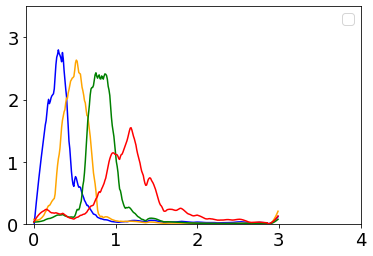

In [4]:
matplotlib.rcParams.update({'font.size':18, 'legend.fontsize':'small'})
plt.figure(figsize=(6,4))

plt.plot(bins_tomo,nz_tomo[0],color='blue',ls='-')#,label='Orig %.3f'%(meannz0[0]))
plt.plot(bins_tomo,nz_tomo[1],color='orange',ls='-')#,label='Orig %.3f'%(meannz0[1]))
plt.plot(bins_tomo,nz_tomo[2],color='green',ls='-')#,label='Orig %.3f'%(meannz0[2]))
plt.plot(bins_tomo,nz_tomo[3],color='red',ls='-')#,label='Orig %.3f'%(meannz0[3]))


plt.legend(fontsize=14,ncol=2)
plt.xlim((-0.1,4))
plt.ylim((0,3.5))

In [8]:
nz_ = np.zeros((len(bins_tomo), 2))
nz_[:,0] = bins_tomo
nz_[:,1] = nz_tomo[3]
np.savetxt('/pscratch/sd/m/myamamot/sample_variance/Y6_bin3_nz_071124.txt', nz_)

## Plot the measured PSF contamination vs xipm (Y3 -- non-tomo)

In [ ]:
y3_xi = fio.read('/global/cfs/cdirs/des/myamamot/2pt_corr/y3_all_dat_vec/y3_gg_nontomo.fits')

In [ ]:
pth = "/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v5b_paper/rho_tau_stats/final_fiducial_8params_16bins_2.5_250_021624/"
with open(os.path.join(pth, "full_correlation_psf_xipxim.pkl"), "rb") as f:
        (   r,
            gp_corr_xip,
            gp_corr_xim,
            pp_corr_xip,
            pp_corr_xim,
        ) = pickle.load(f)
gp_corr_cov_xip = 0 # np.loadtxt(os.path.join(pth, "gp_covariance_psf_sims_xip.txt"))
gp = gp_corr_xip[0, :]
gq = gp_corr_xip[1, :]
gp4 = gp_corr_xip[2, :] 
gq4 = gp_corr_xip[3, :]
gw = gp_corr_xip[4, :]
gw4 = gp_corr_xip[5, :]
gs = gp_corr_xip[6, :]
gt = gp_corr_xip[7, :]
tau_data_xip = [gp, gq, gp4, gq4, gw, gw4, gs, gt, gp_corr_cov_xip, r] 

gp_corr_cov_xim = 0 #np.loadtxt(os.path.join(pth, "gp_covariance_psf_sims_xim.txt"))
gp = gp_corr_xim[0, :]
gq = gp_corr_xim[1, :]
gp4 = gp_corr_xim[2, :] 
gq4 = gp_corr_xim[3, :]
gw = gp_corr_xim[4, :]
gw4 = gp_corr_xim[5, :]
gs = gp_corr_xim[6, :]
gt = gp_corr_xim[7, :]
tau_data_xim = [gp, gq, gp4, gq4, gw, gw4, gs, gt, gp_corr_cov_xim, r]

In [ ]:
chain_path = "/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v5b_paper/rho_tau_stats/final_fiducial_8params_16bins_2.5_250_021624/"
psf_samples = np.loadtxt(chain_path + "flatchain_simgp.txt")
nsims=800; num_of_corr = 8
nbins = 16
idx = np.arange(num_of_corr)
inds = np.random.randint(len(psf_samples), size=800)
xip_contamination = np.zeros((nsims, nbins)); xim_contamination = np.zeros((nsims, nbins))
for ii,ind in enumerate(inds):
    sample = psf_samples[ind]
    
    bestfit_list_xip = []; bestfit_list_xim = []
    for i in idx:
        for j in idx:
            bestfit_list_xip.append(sample[i] * sample[j] * pp_corr_xip[i][j])
            bestfit_list_xim.append(sample[i] * sample[j] * pp_corr_xim[i][j])

    xip_contamination[ii] = np.sum(np.array(bestfit_list_xip), axis=0)
    xim_contamination[ii] = np.sum(np.array(bestfit_list_xim), axis=0)

In [ ]:
mean_xip_contamination = np.mean(xip_contamination, axis=0)
mean_xim_contamination = np.mean(xim_contamination, axis=0)
print(mean_xip_contamination)

In [ ]:
import proplot as pplt
matplotlib.rcParams.update({'font.size':18, 'legend.fontsize':'x-small'})
fig,ax = pplt.subplots(nrows=1, ncols=2, figsize=(12,5), sharex=False, sharey=False)

ax[0].errorbar(y3_xi['meanr'], y3_xi['xip'], yerr=y3_xi['sigma_xip'], fmt='o', label='Y3')
ax[0].plot(r, abs(mean_xip_contamination), lw=1, ls='-', label='PSF systematics contamination')
ax[0].set_xlabel(r'$\theta$')
ax[0].set_ylabel(r'$\xi_{+}$')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylim(1e-9,1e-4)
ax[0].format(yticklabels=['', '$10^{-9}$', '$10^{-8}$', '$10^{-7}$', '$10^{-6}$', '$10^{-5}$', '$10^{-4}$'])
ax[0].legend()

ax[1].errorbar(y3_xi['meanr'], y3_xi['xim'], yerr=y3_xi['sigma_xim'], fmt='o')
ax[1].plot(r, abs(mean_xim_contamination), lw=1, ls='-')
ax[1].set_xlabel(r'$\theta$')
ax[1].set_ylabel(r'$\xi_{-}$')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_ylim(1e-9,1e-4)
ax[1].format(yticklabels=['', '$10^{-9}$', '$10^{-8}$', '$10^{-7}$', '$10^{-6}$', '$10^{-5}$', '$10^{-4}$'])

# 3. Dependence on survey and measured properties

1. Prepare two catalogs split by some properties. 
2. Run sompz to get new n(z)s for the split catalogs.
3. Run y6-cosmicshear pipeline with these new shape and redshift catalogs.
4. Prepare theory DV with the new n(z)s.
5. Compare the theory vs data DVs. 

## Make catalogs split by properties using Theo's mask

In [12]:
mask_dir = '/pscratch/sd/s/schutt20/y6-cosmic-shear/survey_prop_masks_mastercat/'
mastercat = '/global/cfs/cdirs/des/y6-shear-catalogs/master/metadetect_2024-07-29.hdf5'
wf = '/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/inverse_variance_weight_v6.pickle'
# mastercat = '/global/cfs/cdirs/des/y6kp-cats/2024-07-15/desy6kp_cats_2024-07-15.hdf5'

import h5py
import healsparse

mdet = h5py.File(mastercat, 'r')
mdet_groups = [group_name for group_name in mdet]
mdet_bins = [col_name for col_name in mdet[mdet_groups[0]]]
mdet_cols = ['uid'] # [col_name for col_name in mdet[mdet_groups[0]+'/tomo_bin_0']]

In [16]:
mdet_ = h5.File('/global/cfs/cdirs/des/boyan/sompz_data_y6/Metadetect_v6_m2.0/metadetect_cutsv6_blinded_masked_crazycut_w.h5', 'r')
filepath_save = '/global/cfs/cdirs/des/myamamot/metadetect/v6_UNBLINDED_tomodata/survey_split/metadetect_mastercat_0729'
survey_props = ['airmass_i', 'skybrite_i', 'gauss_T_ratio', 'gauss_psf_T', 'gauss_s2n', 'pgauss_g-i']

for prop in survey_props:
    print(prop)
    hdf_mdet_lower = h5py.File('%s_%s_low.h5' % (filepath_save, prop), 'w')
    hdf_mdet_higher = h5py.File('%s_%s_high.h5' % (filepath_save, prop), 'w')
    
    for group_name in mdet_groups:

        h_group_lower = hdf_mdet_lower.create_group(group_name) 
        h_group_higher = hdf_mdet_higher.create_group(group_name)
        for bin_name in mdet_bins:
            
            msk = np.load(mask_dir + '%s_%s_bin%s_top50percent_mask.npy' % (prop, group_name, bin_name[-1]))
            for col_name in mdet_cols:    

                col = mdet['%s/%s'%(group_name, bin_name)][col_name][:]

                if bin_name == 'tomo_bin_0':
                    # Created data set with each column
                    h_group_lower.create_dataset(col_name, data=col[~msk], chunks=True, maxshape=(None,))
                    h_group_higher.create_dataset(col_name, data=col[msk], chunks=True, maxshape=(None,))
                else:
                    # Append data
                    h_group_lower[col_name].resize((h_group_lower[col_name].shape[0] + col[~msk].shape[0]), axis = 0)
                    h_group_lower[col_name][-col[~msk].shape[0]:] = col[~msk]
                    h_group_higher[col_name].resize((h_group_higher[col_name].shape[0] + col[msk].shape[0]), axis = 0)
                    h_group_higher[col_name][-col[msk].shape[0]:] = col[msk]
                    
    hdf_mdet_lower.close()
    hdf_mdet_higher.close()
    mdets = [h5py.File('%s_%s_low.h5' % (filepath_save, prop), 'r'), h5py.File('%s_%s_high.h5' % (filepath_save, prop), 'r')]
    pre = ['low', 'high']

    for i,d in enumerate(mdets):
        ids_all = np.array(mdet_['noshear/uid'][:])
        ids = np.array(d['noshear/uid'][:])
        msk = np.in1d(ids_all, ids)
        f = '%s_mask_%s_%s.npy' % (filepath_save, prop, pre[i])
        np.save(f, msk)

    os.remove('%s_%s_low.h5' % (filepath_save, prop))
    os.remove('%s_%s_high.h5' % (filepath_save, prop))

airmass_i
skybrite_i
gauss_T_ratio
gauss_psf_T
gauss_s2n
pgauss_g-i


## Make catalogs split by properties for step 1.

In [ ]:
def get_split_msk(d, step, value, prop='gauss_s2n', map_file=None, survey_prop=False):
    
    if survey_prop:
        hmap = healsparse.HealSparseMap.read(map_file)
        ra = d['%s'%step]['ra'][:]; dec = d['%s'%step]['dec'][:]
        values = hmap.get_values_pos(ra, dec)
        lower_msk = (values < value)
        higher_msk = (values >= value)
    else:
        d_ = d['%s'%step][prop][:]
        lower_msk = (d_ < value)
        higher_msk = (d_ >= value)
    
    return lower_msk, higher_msk

In [ ]:
import h5py
import healsparse
# mdet = h5py.File('/global/cfs/cdirs/des/y6-shear-catalogs/Y6A2_METADETECT_V6/metadetect_cutsv6_blinded.h5', 'r')
mdet = h5py.File('/global/cfs/cdirs/des/boyan/sompz_data_y6/Wide_lssmasked/metadetect_desdmv5a_cutsv5_patchesv5b_masked_24.5w.h5', 'r')
mdet_groups = [group_name for group_name in mdet] # mdet_groups = [group_name for group_name in d_y6kp['mdet/']]
mdet_cols = [col_name for col_name in mdet[mdet_groups[0]]] # mdet_cols = [col_name for col_name in mdet['mdet'][mdet_groups[0]]]

In [ ]:
filepath_save = '/global/cfs/cdirs/des/myamamot/metadetect/v5b/metadetect_desdmv5a_cutsv5_patchesv5b_masked_24.5w'

hdf_mdet_lower = h5py.File('%s_lows2n.h5' % filepath_save, 'w')
hdf_mdet_higher = h5py.File('%s_highs2n.h5' % filepath_save, 'w')
col_to_split = 'gauss_s2n'
for group_name in mdet_groups:

    print(group_name)
    h_group_lower = hdf_mdet_lower.create_group(group_name) # h_group = hdf_mdet.create_group('mdet/'+group_name)
    h_group_higher = hdf_mdet_higher.create_group(group_name)

    value = np.quantile(mdet['noshear'][col_to_split][:], 0.5)
    msk_lower, msk_higher = get_split_msk(mdet, group_name, value, prop=col_to_split)
    for col_name in mdet_cols:    

        col = mdet['%s'%group_name][col_name][:] # col = d_y6kp['desy6kp/mdet/%s/tomo_bin_%s' % (group_name, str(zbin))][col_name][:]

        # Created data set with each column
        h_group_lower.create_dataset(col_name, data=col[msk_lower])
        h_group_higher.create_dataset(col_name, data=col[msk_higher])

hdf_mdet_lower.close()
hdf_mdet_higher.close()

## Check new n(z)s made by step 2. 

In [25]:
redshift_file_full = tp.TwoPointFile.from_fits('/global/cfs/cdirs/des/boyan/sompz_output/y6_data_10000Tile_final/noshear/weighted_pile3/2pt_modal_even_final_noshear_smooth.fits')
bins_full = redshift_file_full.kernels[0].z
nz_full = redshift_file_full.kernels[0].nzs


redshift_file_lower_half = tp.TwoPointFile.from_fits('/global/cfs/cdirs/des/myamamot/sompz_output/y6_data_10000Tile_final/noshear/s2n_low/2pt_modal_even_s2n_low_smooth.fits')
bins_lower_half = redshift_file_lower_half.kernels[0].z
nz_lower_half = redshift_file_lower_half.kernels[0].nzs

redshift_file_higher_half = tp.TwoPointFile.from_fits('/global/cfs/cdirs/des/myamamot/sompz_output/y6_data_10000Tile_final/noshear/s2n_high/2pt_modal_even_s2n_high_smooth.fits')
bins_higher_half = redshift_file_higher_half.kernels[0].z
nz_higher_half = redshift_file_higher_half.kernels[0].nzs

[-0.05843495  0.0794969   0.21406675  0.34527459  0.47312043  0.59760425
  0.71872607  0.83648588  0.95088368  1.06191948] [0.09716563 0.18441566 0.2705067  0.35543878 0.43921188 0.52182601
 0.60328116 0.68357735 0.76271456 0.8406928 ] [-0.14175941  0.02297785  0.18318552  0.3388636   0.49001209  0.63663099
  0.77872031  0.91628003  1.04931017  1.17781071]


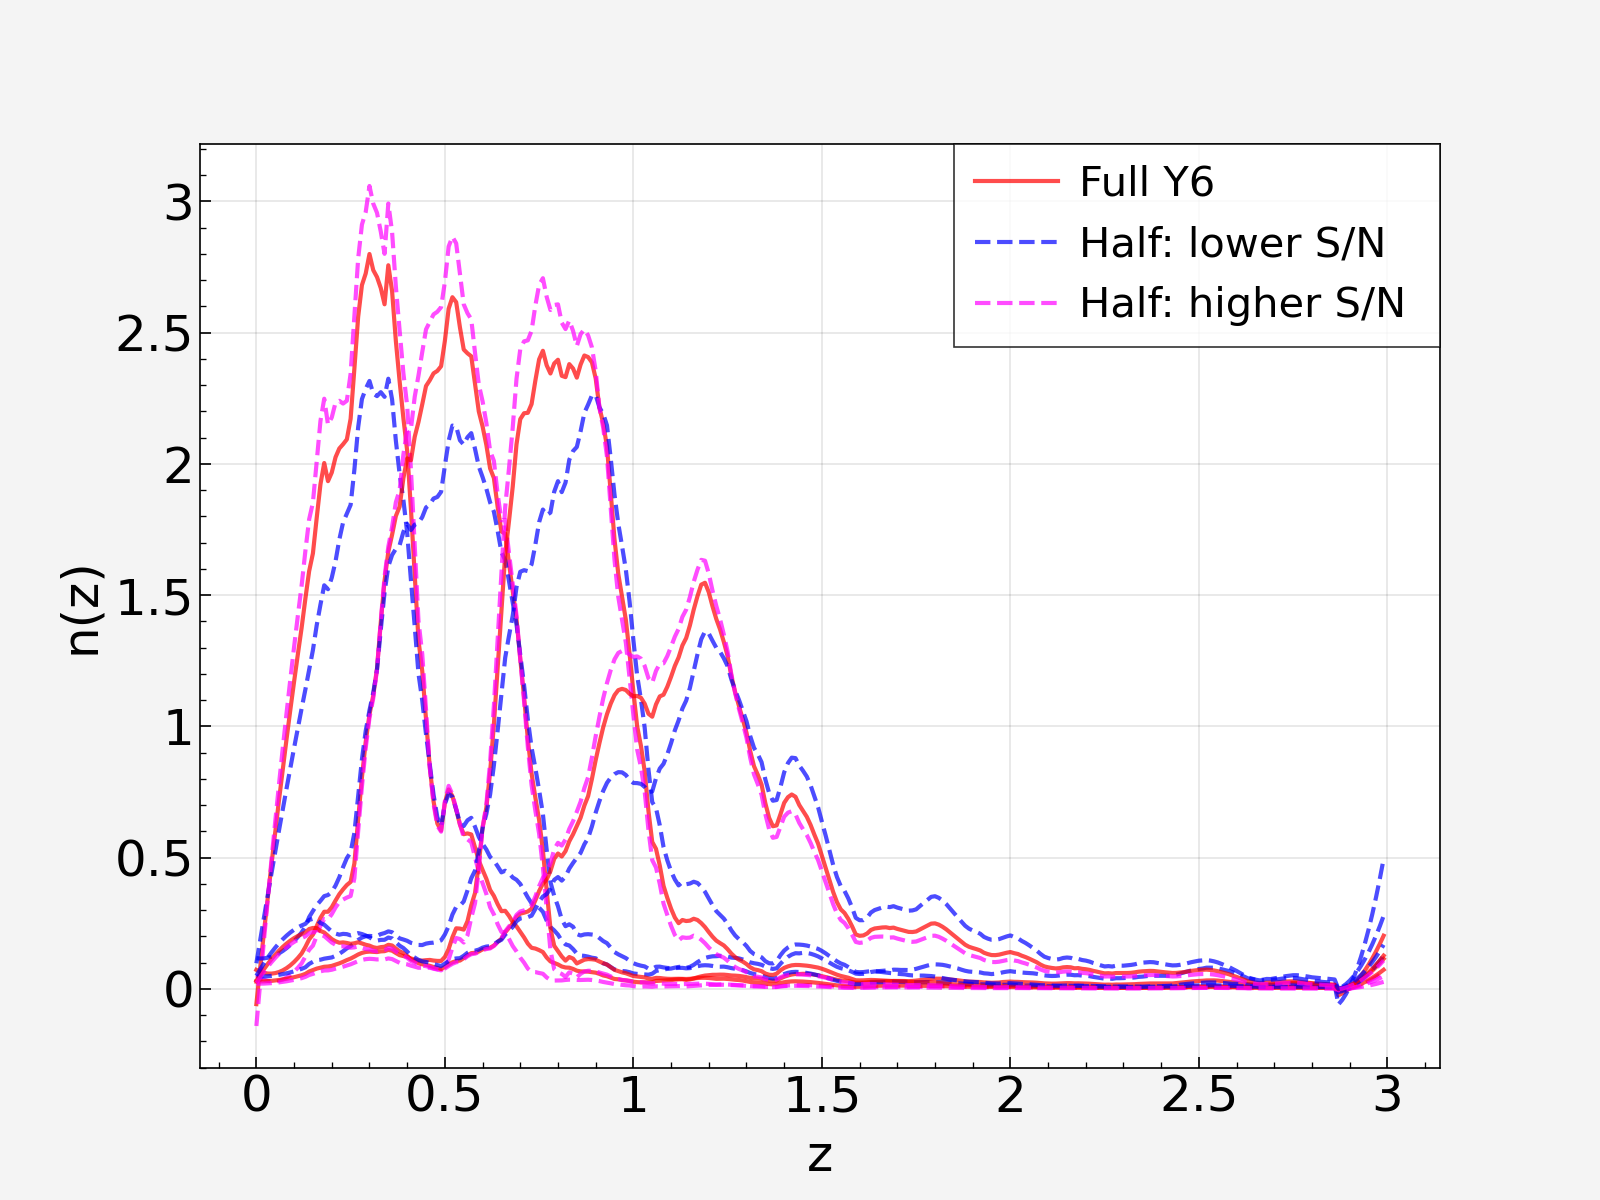

In [27]:
matplotlib.rcParams.update({'font.size':18, 'legend.fontsize':'small'})
plt.figure(figsize=(8,6))

for i in range(4):
    if i == 0:
        print(nz_full[i][:10], nz_lower_half[i][:10], nz_higher_half[i][:10])
        plt.plot(bins_full,nz_full[i], alpha=0.7, color='red',ls='-',label='Full Y6')
        plt.plot(bins_lower_half,nz_lower_half[i], alpha=0.7, color='blue',ls='--',label='Half: lower S/N ')
        plt.plot(bins_higher_half,nz_higher_half[i], alpha=0.7, color='magenta',ls='--',label='Half: higher S/N ')
    else:
        plt.plot(bins_full,nz_full[i], alpha=0.7, color='red',ls='-',)
        plt.plot(bins_lower_half,nz_lower_half[i], alpha=0.7, color='blue',ls='--',)
        plt.plot(bins_higher_half,nz_higher_half[i], alpha=0.7, color='magenta',ls='--',)
plt.xlabel('z')
plt.ylabel('n(z)')
plt.legend()

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

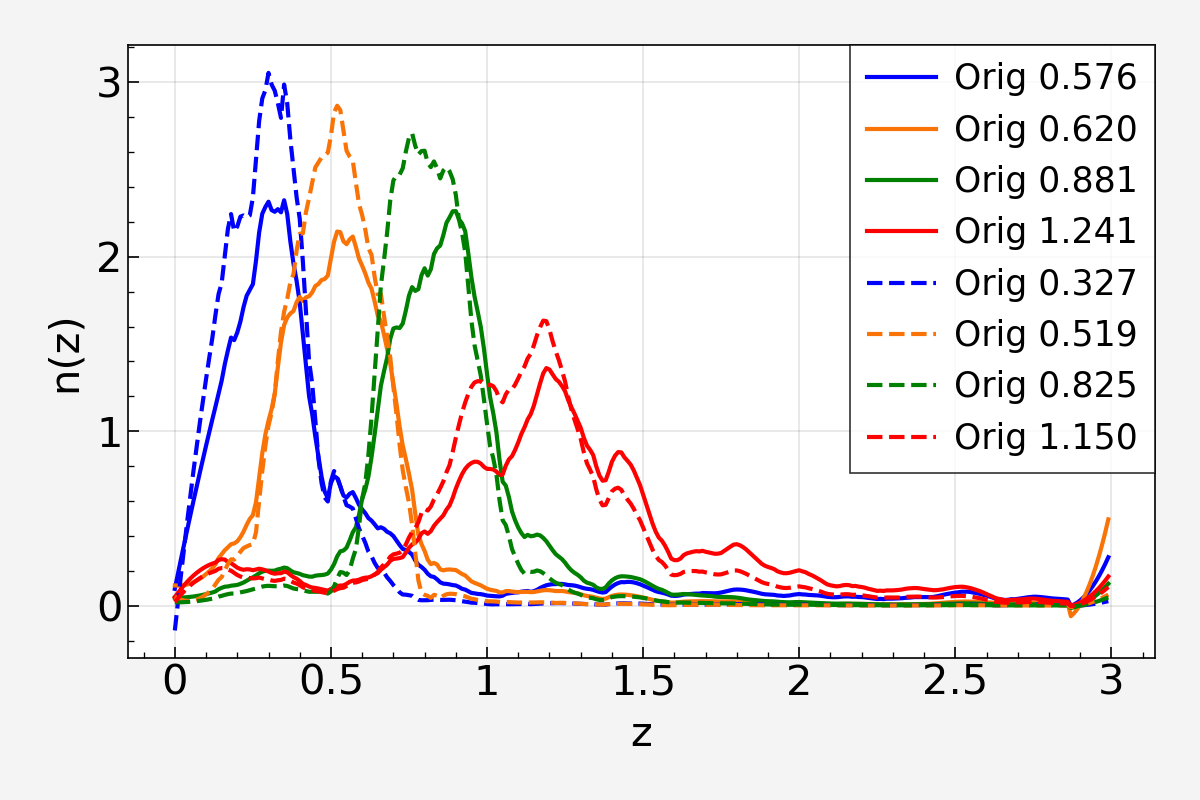

In [31]:
def get_mean(zmeans, hists):
    means = np.zeros(4)
    sigmas = np.zeros(4)
    
    plt.figure(figsize=(12,6))
    bins=['BIN1','BIN2','BIN3','BIN4']
    for i in range(4):
        means[i] = np.sum(hists[bins[i]]*zmeans)/np.sum(hists[bins[i]])        
    return means

nbins = 4

infile_mdet_low = '/global/cfs/cdirs/des/y6-cosmicshear/survey-prop-tests/data-split-2pt-measurements/theory/sim_d-gen2pt_simy6_l-hm20f-nlay6sim-bfix-magy6bal2fix_ml6_sy3-s2n_low.fits' 
infile_mdet_high = '/global/cfs/cdirs/des/y6-cosmicshear/survey-prop-tests/data-split-2pt-measurements/theory/sim_d-gen2pt_simy6_l-hm20f-nlay6sim-bfix-magy6bal2fix_ml6_sy3-s2n_high.fits'
dat_low = fits.open(infile_mdet_low); dat_high = fits.open(infile_mdet_high)

nz_low=dat_low['nz_source'].data; nz_high=dat_high['nz_source'].data
nz_means_low = np.zeros((nbins)); nz_means_high = np.zeros((nbins))
nznorm_low = np.zeros((nbins,len(nz_low))); nznorm_high = np.zeros((nbins,len(nz_high)))

for ibin in range(nbins):
    zmid = nz_low['Z_MID']
    nznorm_low[ibin,:]=nz_low['BIN%d'%(ibin+1)]/np.sum(nz_low['BIN%d'%(ibin+1)]) #normalise
    nz_means_low[ibin] = np.sum(nznorm_low*zmid)
    
    zmid = nz_high['Z_MID']
    nznorm_high[ibin,:]=nz_high['BIN%d'%(ibin+1)]/np.sum(nz_high['BIN%d'%(ibin+1)]) #normalise
    nz_means_high[ibin] = np.sum(nznorm_high*zmid)
    

meannz_low=get_mean(dat_low['nz_source'].data['Z_MID'], dat_low['nz_source'].data)
meannz_high=get_mean(dat_high['nz_source'].data['Z_MID'], dat_high['nz_source'].data)


matplotlib.rcParams.update({'font.size':15, 'legend.fontsize':'small'})
plt.figure(figsize=(6,4))

plt.plot(dat_low['nz_source'].data['Z_MID'],dat_low['nz_source'].data['BIN1'],color='blue',ls='-',label='Orig %.3f'%(meannz_low[0]))
plt.plot(dat_low['nz_source'].data['Z_MID'],dat_low['nz_source'].data['BIN2'],color='orange',ls='-',label='Orig %.3f'%(meannz_low[1]))
plt.plot(dat_low['nz_source'].data['Z_MID'],dat_low['nz_source'].data['BIN3'],color='green',ls='-',label='Orig %.3f'%(meannz_low[2]))
plt.plot(dat_low['nz_source'].data['Z_MID'],dat_low['nz_source'].data['BIN4'],color='red',ls='-',label='Orig %.3f'%(meannz_low[3]))

plt.plot(dat_high['nz_source'].data['Z_MID'],dat_high['nz_source'].data['BIN1'],color='blue',ls='--',label='Orig %.3f'%(meannz_high[0]))
plt.plot(dat_high['nz_source'].data['Z_MID'],dat_high['nz_source'].data['BIN2'],color='orange',ls='--',label='Orig %.3f'%(meannz_high[1]))
plt.plot(dat_high['nz_source'].data['Z_MID'],dat_high['nz_source'].data['BIN3'],color='green',ls='--',label='Orig %.3f'%(meannz_high[2]))
plt.plot(dat_high['nz_source'].data['Z_MID'],dat_high['nz_source'].data['BIN4'],color='red',ls='--',label='Orig %.3f'%(meannz_high[3]))

plt.xlabel('z')
plt.ylabel('n(z)')
plt.legend()
plt.tight_layout()

## Make template files with new n(z)s for step 4. 

In [21]:
# 'airmass_i', 'skybrite_i', 'gauss_T_ratio', 'gauss_psf_T', 'gauss_s2n', 'pgauss_g-i'
fits_file = fio.FITS('/pscratch/sd/m/myamamot/y6-3x2pt-methods/cosmosis/data_vectors/Template_DV5.0.fits')
redshift_file = '/global/cfs/cdirs/des/myamamot/sompz_output/y6_data_10000Tile_final/noshear/pgauss_g-i_low/sompz_y6_pgauss_g-i_low.hdf5'
out_file = fio.FITS('/pscratch/sd/m/myamamot/y6-3x2pt-methods/cosmosis/data_vectors/Template_DV5.0_pgauss_g-i_low.fits','rw')


def copy_header(f, name, out_f):
    # this generically copies over a HDU from the template file
    # for the moment we want to do this for gammat and wtheta
    # as placeholders until we have the real thing

    hdr = f[name].read_header()
    data = f[name].read()

    out_f.write(data)
    out_f[-1].write_key('EXTNAME',name)
    for k in hdr.keys():
        if k=='EXTNAME':
            continue

        out_f[-1].write_key(k,hdr[k])

    print('done copying %s'%name)

def copy_covariance(f, out_f):
    # this basically just copies across an analytic covariance matrix
    C = f['COVMAT'].read()
    hdr = f['COVMAT'].read_header()

    out_f.write(C)
    out_f[-1].write_key('EXTNAME', 'COVMAT')
    out_f[-1].write_key('STRT_0', hdr['STRT_0'])
    out_f[-1].write_key('NAME_0', 'xip')
    out_f[-1].write_key('STRT_1', hdr['STRT_1'])
    out_f[-1].write_key('NAME_1', 'xim')

    out_f[-1].write_key('STRT_2', hdr['STRT_2'])
    out_f[-1].write_key('NAME_2', 'gammat')
    out_f[-1].write_key('STRT_3', hdr['STRT_3'])
    out_f[-1].write_key('NAME_3', 'wtheta')

f_nz = h5.File(redshift_file, 'r')
data = f_nz.get('/catalog/sompz/pzdata')
z_low = data['zlow'][:]
z_high = data['zhigh'][:]
z_mid = (z_low+z_high)/2

nz = 0
for n in data.keys():
    if 'bin' in n:
        nz+=1

print('found %d redshift bins'%nz)
info_nz = {'Z_LOW': z_low, 'Z_MID': z_mid,'Z_HIGH': z_high}

for i in range(nz):
    info_nz['BIN%d' % (i + 1)] = data['bin%d' % i][:]

out_file.write(info_nz)
out_file[-1].write_key('EXTNAME', 'nz_source')

# copy_header(fits_file, 'nz_source', out_file)
copy_header(fits_file, 'nz_lens', out_file)
copy_header(fits_file, 'xip', out_file)
copy_header(fits_file, 'xim', out_file)
copy_header(fits_file, 'gammat', out_file)
copy_header(fits_file, 'wtheta', out_file)


# Add covariance
copy_covariance(fits_file, out_file)


out_file.close()

found 4 redshift bins
done copying nz_lens
done copying xip
done copying xim
done copying gammat
done copying wtheta


### Non-tomographic

In [ ]:
# fits_file = fio.FITS('/global/cfs/cdirs/des/myamamot/2pt_corr/sim_d-gen2pt_simy6_l-desy3-hm20f-tatty6sim-bfix-nlbias_ml6_sy3-covcNG-mask.fits')
template_file = fio.FITS('/global/cfs/cdirs/des/myamamot/y6-cosmicshear/mdet/measurements/y6_mdetV5_highs2n_blindcat.fits')
nz_file = '/global/cfs/cdirs/des/myamamot/sompz_output/y6_data_5000Tile_24.5/noshear/noweight_highs2n/sompz_5000Tile.hdf5'
xi_file = None
tmin = 2.5; tmax = 250
nt = 20
bin_slop = 0.1

In [ ]:
# new file
out_file = fio.FITS('/global/homes/m/myamamot/DES/y6-3x2pt-methods/cosmosis/data_vectors/nz_split/fits_nz_template_highs2n_2.5_250_20.fits','rw')

f_nz = h5.File(nz_file)
data = f_nz.get('/catalog/sompz/pzdata')
z_low = data['zlow'][:]
z_high = data['zhigh'][:]
z_mid = (z_low+z_high)/2

nz = 0
for n in data.keys():
    if 'bin' in n:
        nz+=1

print('found %d redshift bins'%nz)
info_nz = {'Z_LOW': z_low, 'Z_MID': z_mid,'Z_HIGH': z_high}

for i in range(nz):
    info_nz['BIN%d' % (i + 1)] = data['bin%d' % i][:]

out_file.write(info_nz)
out_file[-1].write_key('EXTNAME', 'nz_source')


# add theta info
info_xip = {'BIN1': [],'BIN2': [],'ANGBIN': [],'VALUE': [],'ANG': [],'ANGLEMIN': [],'ANGLEMAX': []}
info_xim = {'BIN1': [],'BIN2': [],'ANGBIN': [],'VALUE': [],'ANG': [],'ANGLEMIN': [],'ANGLEMAX': []}

theta_edges = np.logspace(np.log10(float(tmin)), np.log10(float(tmax)), int(nt)+1)
theta_low = theta_edges[:-1]
theta_high = theta_edges[1:]
ntheta = int(nt)
    
nbin = 0
# we need the bins in a specific order to match the covariance matrix
# so we'll use a pre-existing FITS file to get the indices
bin1 = template_file['xip'].read()['BIN1']
bin2 = template_file['xip'].read()['BIN2']
done = []

# loop over the text files
for i,j in zip(bin1,bin2):
    if '%d%d'%(i,j) in done:
        continue
        
    filename = '/global/cfs/cdirs/des/myamamot/y6-cosmicshear/mdet/' + 'measurements/xipm_'
    filename += 'y6_mdetV5_lows2n_blindcat_v5cuts_bin'
    filename += '_%d_%d_%1.3fslop_%1.1ftheta%1.1f.txt' % (i, j, float(bin_slop), float(tmin), float(tmax))

    # now read the file
    theta, xip, xim, _, _, _ = np.loadtxt(filename).T
    i_theta = np.arange(0, len(theta), 1)

    info_xip['VALUE'].append(xip)
    info_xip['ANG'].append(theta)
    info_xip['ANGLEMIN'].append(theta_low)
    info_xip['ANGLEMAX'].append(theta_high)
    info_xip['ANGBIN'].append(i_theta.astype(int))
    info_xip['BIN1'].append((np.zeros_like(xip) + i).astype(int))
    info_xip['BIN2'].append((np.zeros_like(xip) + j).astype(int))

    info_xim['VALUE'].append(xim)
    info_xim['ANG'].append(theta)
    info_xim['ANGLEMIN'].append(theta_low)
    info_xim['ANGLEMAX'].append(theta_high)
    info_xim['ANGBIN'].append(i_theta.astype(int))
    info_xim['BIN1'].append((np.zeros_like(xim) + i).astype(int))
    info_xim['BIN2'].append((np.zeros_like(xim) + j).astype(int))

    nbin += 1
    done.append('%d%d'%(i,j))

# flatten the arrays
for k in info_xip.keys():
    info_xip[k] = np.concatenate(info_xip[k])
    info_xim[k] = np.concatenate(info_xim[k])

out_file.write(info_xip)

out_file[-1].write_key('EXTNAME', 'xip')
out_file[-1].write_key('KERNEL_1', 'nz_source')
out_file[-1].write_key('KERNEL_2', 'nz_source')
out_file[-1].write_key('WINDOWS', 'SAMPLE')
out_file[-1].write_key('N_ZBIN_1', 4)
out_file[-1].write_key('N_ZBIN_2', 4)
out_file[-1].write_key('N_ANG', ntheta)
out_file[-1].write_key('TUNIT5', 'arcmin')
out_file[-1].write_key('TUNIT6', 'arcmin')
out_file[-1].write_key('TUNIT7', 'arcmin')
out_file[-1].write_key('2PTDATA', True)
out_file[-1].write_key('QUANT1', 'G+R')
out_file[-1].write_key('QUANT2', 'G+R')

out_file.write(info_xim)

out_file[-1].write_key('EXTNAME', 'xim')
out_file[-1].write_key('KERNEL_1', 'nz_source')
out_file[-1].write_key('KERNEL_2', 'nz_source')
out_file[-1].write_key('WINDOWS', 'SAMPLE')
out_file[-1].write_key('N_ZBIN_1', 4)
out_file[-1].write_key('N_ZBIN_2', 4)
out_file[-1].write_key('N_ANG', ntheta)
out_file[-1].write_key('TUNIT5', 'arcmin')
out_file[-1].write_key('TUNIT6', 'arcmin')
out_file[-1].write_key('TUNIT7', 'arcmin')
out_file[-1].write_key('2PTDATA', True)
out_file[-1].write_key('QUANT1', 'G-R')
out_file[-1].write_key('QUANT2', 'G-R')


C = template_file['COVMAT'].read()
# C_ = np.random.rand(nt*2, nt*2)
# C = np.dot(C_, C_.transpose())
hdr = template_file['COVMAT'].read_header()
out_file.write(C)
out_file[-1].write_key('EXTNAME', 'COVMAT')
out_file[-1].write_key('STRT_0', hdr['STRT_0'])
out_file[-1].write_key('NAME_0', 'xip')
out_file[-1].write_key('STRT_1', hdr['STRT_1'])
out_file[-1].write_key('NAME_1', 'xim')


out_file.close()

## Plot and compare DVs from data and theory for split samples

In [3]:
filepath_save = '/global/cfs/cdirs/des/y6-cosmicshear/survey-prop-tests/data-split-2pt-measurements'
filepath_methods = '/pscratch/sd/m/myamamot/y6-3x2pt-methods/cosmosis/data_vectors/'
infile_mdet_low = os.path.join(filepath_save, 'unblinded/y6_mastermdetV6_UNBLINDED_survey-prop_gauss_s2n_lower.fits')
infile_theory_low = os.path.join(filepath_save, 'theory/sim_d-gen2pt_simy6_l-hm20f-nlay6sim-bfix-magy6bal2fix_ml6_sy3-s2n_low.fits')
infile_mdet_high = os.path.join(filepath_save, 'unblinded/y6_mastermdetV6_UNBLINDED_survey-prop_gauss_s2n_upper.fits')
infile_theory_high = os.path.join(filepath_save, 'theory/sim_d-gen2pt_simy6_l-hm20f-nlay6sim-bfix-magy6bal2fix_ml6_sy3-s2n_high.fits')

In [4]:
infile_theory_low_s8 = os.path.join(filepath_methods, 'survey_prop/s8/sim_d-gen2pt_simy6_l-hm20f-nlay6sim-bfix-magy6bal2fix_ml6_sy3-s2n_low.fits')
infile_theory_high_s8 = os.path.join(filepath_methods, 'survey_prop/s8/sim_d-gen2pt_simy6_l-hm20f-nlay6sim-bfix-magy6bal2fix_ml6_sy3-s2n_high.fits')

### Comapre two theory DVs

123
0 0.5
xip 1 1
yes!
Abc
yes!
yes!
yes!
yes!
yes!
yes!
xim 1 4
yes!
xim 2 4


findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


xim 3 4
xim 4 4


findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


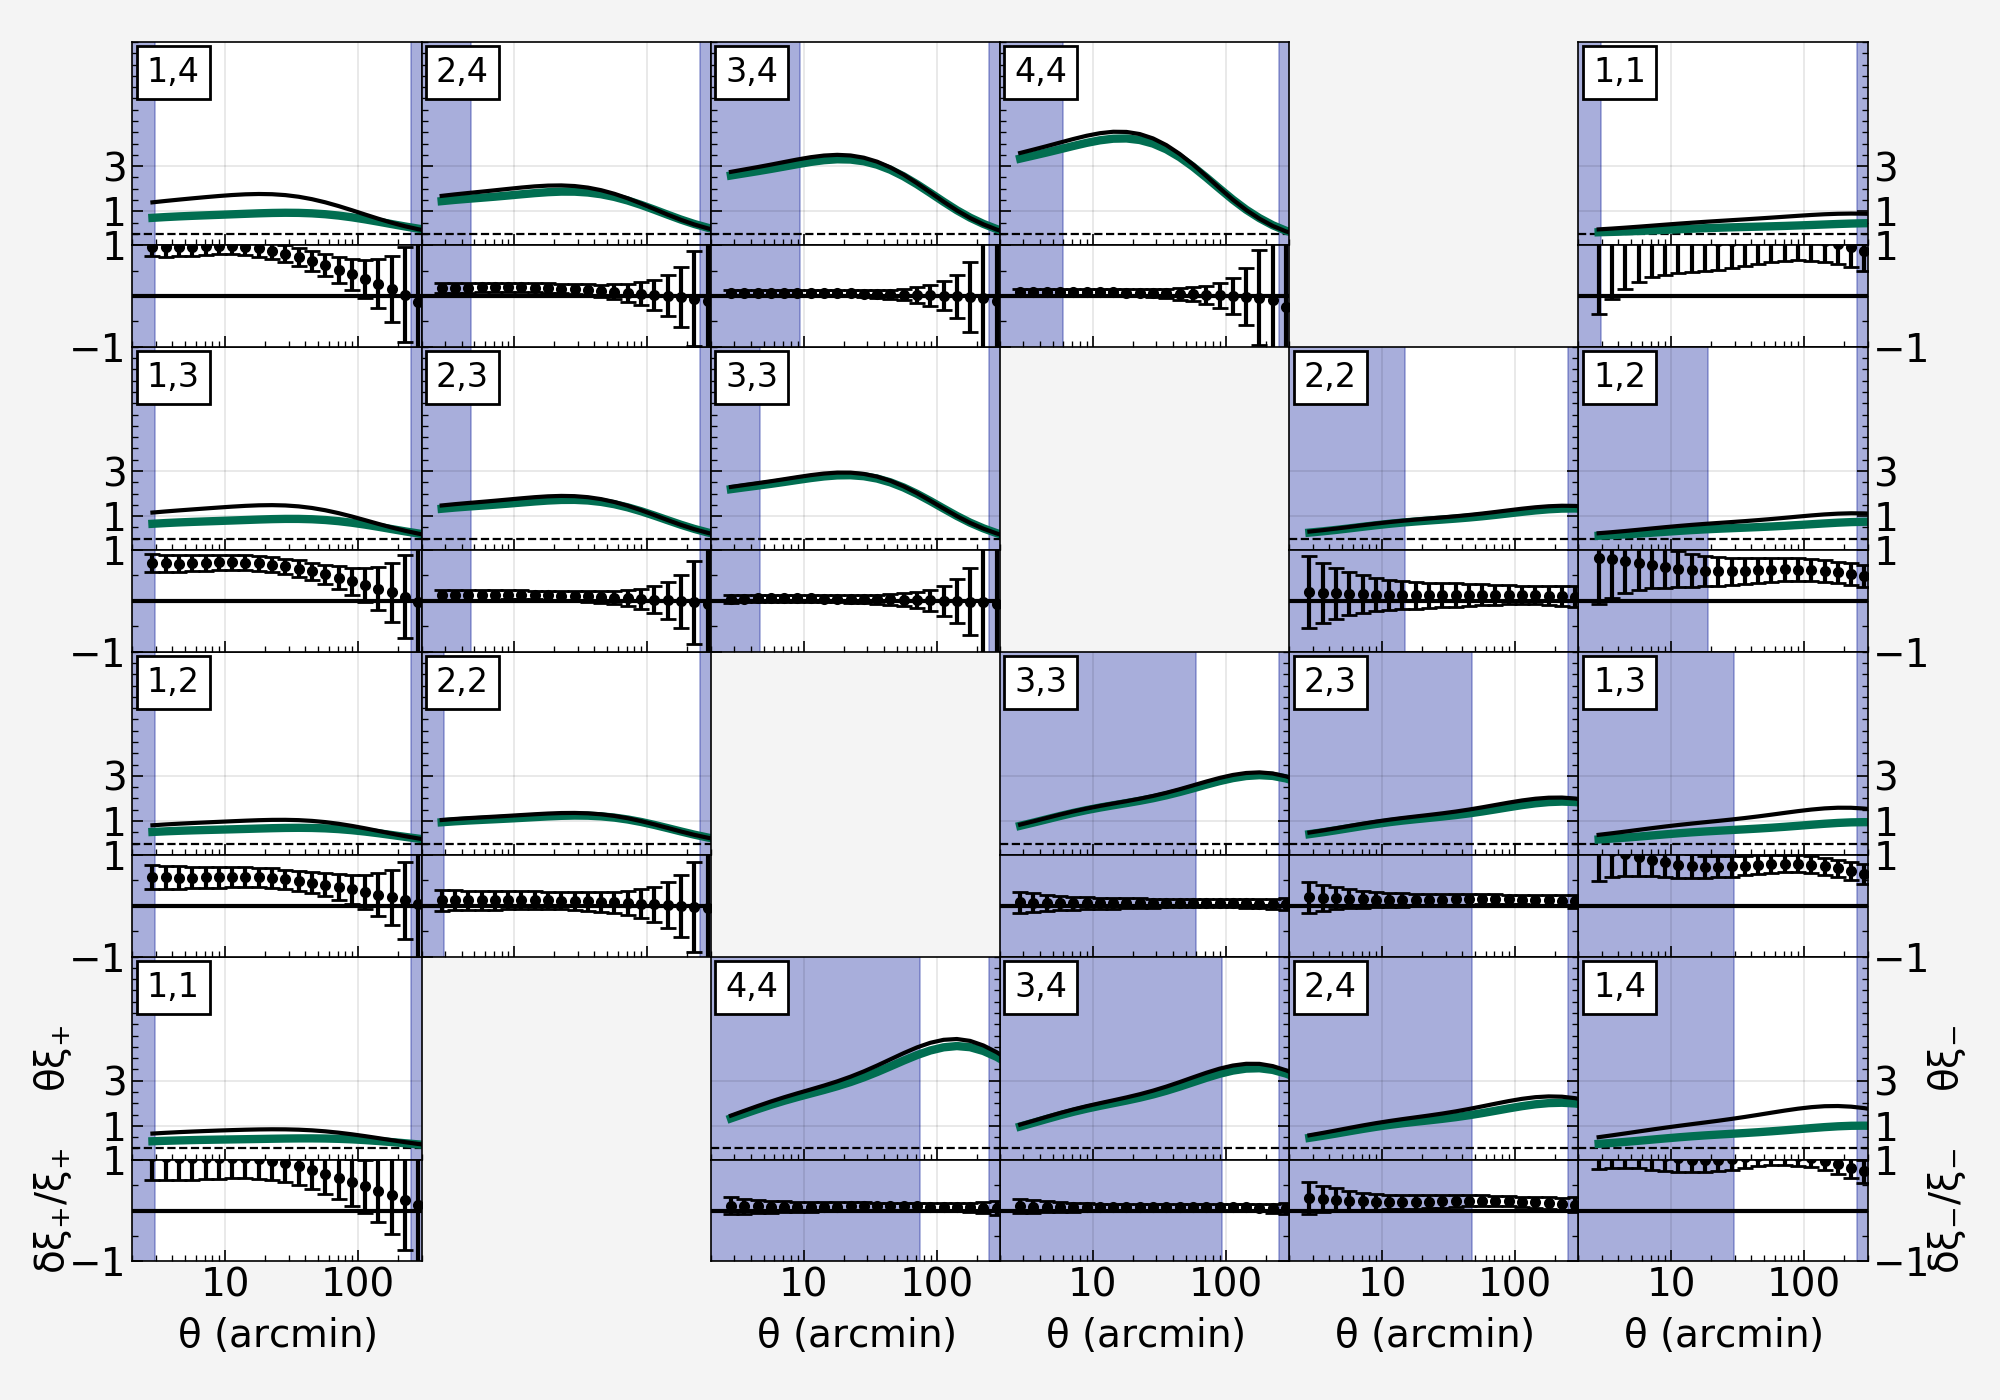

In [6]:
log=False
matplotlib.rcParams["xtick.direction"]='in'
matplotlib.rcParams["ytick.direction"]='in'

def get_axes_(name,i,j,rows,cols,dxi=False):
    if not dxi:
        if name == 'xip':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(3-(j-1)),i-1),rowspan=2)
        elif name=='xim':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(j-1),6-i),rowspan=2)
    else:
        if name == 'xip':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(3-(j-1))+2,i-1))
        elif name=='xim':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(j-1)+2,6-i))
    return ax


def get_angle_range_agg(xi,j,i):
    config = configparser.ConfigParser()
    config.read(scfile)
    scales = config['2pt_like']
    if xi == 'xip':
        name = 'angle_range_xip_'+str(j)+'_'+str(i)
    else:
        name = 'angle_range_xim_'+str(j)+'_'+str(i)
        #print(name, str(j), str(i), np.array(scales[name].split()).astype(float))
    return np.array(scales[name].split()).astype(float)

def get_angle_range(xi,j,i):
    config = configparser.ConfigParser()
    config.read(scfile)
    scales = config['2pt_like']

    if xi == 'xip':
        name = 'angle_range_xip_'+str(j)+'_'+str(i)
    else:
        name = 'angle_range_xim_'+str(j)+'_'+str(i)
    return np.array(scales[name].split()).astype(float)

def get_params(xi,theta):
    if xi == 'xip' or xi == 'xim':
        #lims = [(-0.5,4.4),(0.,4.4),(0.,4.4),(0.,4.4)]#[(-0.4,1.2),(-0.4,1.6),(-0.6,3.),(-0.6,4.45)]
        lims = [(-0.5,8.5),(-0.5,8.5),(-0.5,8.5),(-0.5,8.5)]#[(-0.4,1.2),(-0.4,1.6),(-0.6,3.),(-0.6,4.45)]


        dlims = [(-1.5,1.5) for i in range(4)]
        tmult = theta
        dmult = 1e4
        dmult2 = 1e4
        lx = [0.05, 0.93]
    return lims, dlims,tmult,dmult,dmult2,lx

def set_axes(name,ax,dxi=False):
    if not dxi:
        if (name=='xim')&(i==1):
            plt.xlabel(r'$\theta$ [arcmin]')
        else:
            ax.set_xticklabels([])
        if i!=1:
            ax.set_yticklabels([])
        if (i==1)&(j==1):
            if name == 'xip':
                print("123")
                # plt.ylabel(r'$   10^{4}\theta\xi_{+}    $', labelpad=15) 
                plt.ylabel(r'$\theta\xi_{+}    $', labelpad=15) 
                x,y = ax.yaxis.label.get_position()
                print(x,y)
                ax.yaxis.set_label_coords(x-.2, y)#-0.5
        if (i==1)&(j==4):
            if name == 'xim':
                # plt.ylabel(r'$   10^{4}\theta\xi_{-}     $')
                plt.ylabel(r'$\theta\xi_{-}    $', labelpad=15) 
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x+1.2, y)#+0.5
                ax.yaxis.set_label_position("right")
    else:
        if (name=='xim')&(j==4): #&(j==4):
            print(name,i,j)
            plt.xlabel(r'$\theta$ (arcmin)')
        elif (name=='xip')&(i==1)&(j==1):
            print(name,i,j)
            plt.xlabel(r'$\theta$ (arcmin)')
        if (name=='xim')&(j<3):
            ax.set_xticklabels([])
        if (name=='xip')&(j!=1):
        #else:
            ax.set_xticklabels([])
        
        if (name=='xip')&(i==1):
            print("yes!")
            #ax.set_yticklabels([])
        elif (name=='xim')&(i==1):
            print("yes!")
        else:
            ax.set_yticklabels([])
            
        if (i==1)&(j==1):
            if name == 'xip':
                print("Abc")
                plt.ylabel(r'$\delta\xi_{+}/\xi_{+}      $')
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x-.2, y)#-0.5
        if (i==1)&(j==4):
            if name == 'xim':
                plt.ylabel(r'$\delta\xi_{-}/\xi_{-}      $')
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x+1.2, y)#+0.5
                ax.yaxis.set_label_position("right")


def plot_panel_(name,i,j,rows,cols,theta,xi,err,ttheta,txi,notomo=False):
    lims, dlims,tmult,dmult,dmult2,lx = get_params(name,theta)
    ax = get_axes_(name,i,j,rows,cols)
    tmin,tmax = get_angle_range(name,i,j)
    tmin2,tmax2 = get_angle_range_agg(name,i,j)
    ax.axhline(y=0,ls='--',color='k',lw=0.8)

    from matplotlib.ticker import ScalarFormatter
    for axis in [ax.xaxis, ax.yaxis]:
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        axis.set_major_formatter(formatter)
    ax.plot(ttheta,tmult*txi*dmult,ls='-',color = '#016e51',linewidth=3.)
    # ax.errorbar(theta,tmult*xi*dmult,yerr=err*tmult*dmult,ls='',marker='.',color = 'k')
    # ax.plot(theta,tmult*xi*dmult,ls='',marker='.',color = 'k')
    ax.plot(theta,tmult*xi*dmult,ls='-', color = 'k')
    ax.set_rasterization_zorder(0)
    if txi is None:
        print('faking theory')
        txi = fake_theory(xi)

    plt.ylim(lims[j-1])
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    ax.text(lx[0], lx[1], str(i)+','+str(j), transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)
    plt.xlim((2,300))
    #plt.ticklabel_format(axis='x',style='plain',useOffset=False)    
    set_axes(name,ax,)
    plt.yticks((1.0,3.0))
    plt.xscale('log')
    ax.set_xlabel('')
    #ax.ticklabel_format(style='plain')
    plt.minorticks_on()
    if name == 'xim':
        ax.yaxis.tick_right()
    #ax.spines[axis].set_linewidth(0.5)
    
    ax = get_axes_(name,i,j,rows,cols,dxi=True)
    tmin,tmax = get_angle_range(name,i,j)
    ax.axhline(y=0,ls='-',color='k')
    ax.errorbar(theta,(xi-txi)/txi,yerr=err/txi,ls='',marker='.',color = 'k')
    ax.set_rasterization_zorder(0)
    plt.ylim(-1.0,1.0)
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    #props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    #ax.text(0.03, 0.93, str(i)+','+str(j), transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    plt.xlim((2,300))
    plt.yticks((-1.0,1.0))
    plt.xscale('log')
    # plt.yscale('symlog',linthreshy=.01,linscale=0.01)
    from matplotlib.ticker import FuncFormatter
    x=theta
    formatter = FuncFormatter(lambda x, _: '{:.16g}'.format(x)) # https://stackoverflow.com/a/49306588/3904031
    ax.xaxis.set_major_formatter(formatter)
    set_axes(name,ax,dxi=True)
    #plt.minorticks_on()
    if name == 'xim':
        ax.yaxis.tick_right()
        
#PLOT DATA VECTOR

import proplot as pplt
plt.figure(figsize=(10,7))
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 14,
    "font.serif": ["Times New Roman"],
})
# matplotlib.rcParams.update({'font.size': 14, 'legend.fontsize':'small', 'lines.markersize': 4, 'axes.labelsize': 14, "text.usetex": False, "font.family": "serif", "font.serif": ["Times New Roman"]})
# plt.figure(figsize=(12,8))

fits   = infile_theory_low_s8
tfits  =  infile_theory_high_s8

xip_   = tp.TwoPointFile.from_fits(fits).get_spectrum('xip')
xim_   = tp.TwoPointFile.from_fits(fits).get_spectrum('xim')
txip_   = tp.TwoPointFile.from_fits(tfits,covmat_name=None).get_spectrum('xip')
txim_   = tp.TwoPointFile.from_fits(tfits,covmat_name=None).get_spectrum('xim')
pairs  = xip_.bin_pairs
rowcols = np.max(xip_.bin2)
#print(rowcols)

for k,(i,j) in enumerate(pairs):
    theta  = xip_.get_pair(i,j)[0]
    xip    = xip_.get_pair(i,j)[1]
    xim    = xim_.get_pair(i,j)[1]
    xiperr = xip_.get_error(i,j)
    ximerr = xim_.get_error(i,j)
    txip    = txip_.get_pair(i,j)[1]
    txim    = txim_.get_pair(i,j)[1]

    plot_panel_('xip',i,j,rowcols,rowcols,theta,xip,xiperr,theta,txip,notomo=False)
    plot_panel_('xim',i,j,rowcols,rowcols,theta,xim,ximerr,theta,txim,notomo=False)

plt.tight_layout()
plt.subplots_adjust(hspace=0,wspace=0)
# plt.savefig(dir+'DVcomp.pdf', dpi=150,bbox_inches='tight')
plt.show()
plt.close()

### Compare data - theory

In [30]:
import configparser
log=False
matplotlib.rcParams["xtick.direction"]='in'
matplotlib.rcParams["ytick.direction"]='in'

def fake_theory(xi):
    return savgol_filter(xi, 11, 2)



def get_angle_range(xi,j,i):
    config = configparser.ConfigParser()
    config.read(scfile)
    scales = config['2pt_like']

    if xi == 'xip':
        name = 'angle_range_xip_'+str(j)+'_'+str(i)
    else:
        name = 'angle_range_xim_'+str(j)+'_'+str(i)
    return np.array(scales[name].split()).astype(float)

def get_angle_range_agg(xi,j,i):
    config = configparser.ConfigParser()
    config.read(scfile)
    scales = config['2pt_like']
    if xi == 'xip':
        name = 'angle_range_xip_'+str(j)+'_'+str(i)
    else:
        name = 'angle_range_xim_'+str(j)+'_'+str(i)
        #print(name, str(j), str(i), np.array(scales[name].split()).astype(float))
    return np.array(scales[name].split()).astype(float)

def get_params(xi,theta):
    if xi == 'xip' or xi == 'xim':
        #lims = [(-0.5,4.4),(0.,4.4),(0.,4.4),(0.,4.4)]#[(-0.4,1.2),(-0.4,1.6),(-0.6,3.),(-0.6,4.45)]
        lims = [(-0.5,4.5),(-0.5,4.5),(-0.5,4.5),(-0.5,4.5)]#[(-0.4,1.2),(-0.4,1.6),(-0.6,3.),(-0.6,4.45)]


        dlims = [(-1.5,1.5) for i in range(4)]
        tmult = theta
        dmult = 1e4
        dmult2 = 1e4
        lx = [0.05, 0.93]
    return lims, dlims,tmult,dmult,dmult2,lx

def set_axes(name,ax,dxi=False):
    if not dxi:
        if (name=='xim')&(i==1):
            plt.xlabel(r'$\theta$ [arcmin]')
        else:
            ax.set_xticklabels([])
        if i!=1:
            ax.set_yticklabels([])
        if (i==1)&(j==1):
            if name == 'xip':
                print("123")
                # plt.ylabel(r'$   10^{4}\theta\xi_{+}    $', labelpad=15) 
                plt.ylabel(r'$\theta\xi_{+}    $', labelpad=15) 
                x,y = ax.yaxis.label.get_position()
                print(x,y)
                ax.yaxis.set_label_coords(x-.2, y)#-0.5
        if (i==1)&(j==4):
            if name == 'xim':
                # plt.ylabel(r'$   10^{4}\theta\xi_{-}     $')
                plt.ylabel(r'$\theta\xi_{-}    $', labelpad=15) 
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x+1.2, y)#+0.5
                ax.yaxis.set_label_position("right")
    else:
        if (name=='xim')&(j==4): #&(j==4):
            print(name,i,j)
            plt.xlabel(r'$\theta$ (arcmin)')
        elif (name=='xip')&(i==1)&(j==1):
            print(name,i,j)
            plt.xlabel(r'$\theta$ (arcmin)')
        if (name=='xim')&(j<3):
            ax.set_xticklabels([])
        if (name=='xip')&(j!=1):
        #else:
            ax.set_xticklabels([])
        
        if (name=='xip')&(i==1):
            print("yes!")
            #ax.set_yticklabels([])
        elif (name=='xim')&(i==1):
            print("yes!")
        else:
            ax.set_yticklabels([])
            
        if (i==1)&(j==1):
            if name == 'xip':
                print("Abc")
                plt.ylabel(r'$\delta\xi_{+}/\xi_{+}      $')
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x-.2, y)#-0.5
        if (i==1)&(j==4):
            if name == 'xim':
                plt.ylabel(r'$\delta\xi_{-}/\xi_{-}      $')
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x+1.2, y)#+0.5
                ax.yaxis.set_label_position("right")

                
                
def get_axes(name,i,j,rows,cols,dxi=True):
    if dxi:
        if name == 'xip':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(3-(j-1)),i-1),rowspan=2, )
        elif name=='xim':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(j-1),6-i),rowspan=2, )
    else:
        if name == 'xip':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(3-(j-1))+2,i-1))
        elif name=='xim':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(j-1)+2,6-i))

    return ax

def get_axes_sim(name,i,j,rows,cols,dxi=False):
    if name == 'xip':
        ax = plt.subplot2grid((cols,rows+2), ((3-(j-1)),i-1))
    elif name=='xim':
        ax = plt.subplot2grid(( cols,rows+2), ((j-1),6-i))
    
    return ax


def plot_panel(name,i,j,rows,cols,theta,xi,err,notomo=False):
    lims, dlims,tmult,dmult,dmult2,lx = get_params(name,theta)
    ax = get_axes_sim(name,i,j,rows,cols, dxi=True)
    tmin,tmax = get_angle_range(name,i,j)
    tmin2,tmax2 = get_angle_range_agg(name,i,j)
    ax.axhline(y=0,ls='--',color='k',lw=0.8)

    from matplotlib.ticker import ScalarFormatter
    for axis in [ax.xaxis, ax.yaxis]:
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        axis.set_major_formatter(formatter)
    # ax.plot(ttheta,tmult*txi*dmult,ls='-',color = '#016e51',linewidth=3.)
    ax.errorbar(theta,tmult*xi*dmult,yerr=err*tmult*dmult,ls='',marker='.',color = 'k')
    ax.plot(theta,tmult*xi*dmult,ls='',marker='.',color = 'k')
    ax.set_rasterization_zorder(0)

    plt.ylim(lims[j-1])
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    ax.text(lx[0], lx[1], str(i)+','+str(j), transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    plt.xlim((2,300))
    #plt.ticklabel_format(axis='x',style='plain',useOffset=False)    
    set_axes(name,ax,)
    # plt.yticks((1.0,3.0))
    plt.yticks([])
    plt.xscale('log')
    # ax.set_xlabel(r'$\theta$ [arcmin]')
    # ax.set_ylabel('')
    #ax.ticklabel_format(style='plain')
    plt.minorticks_on()
    if (name=='xim')&(j==4):
        plt.xlabel(r'$\theta$ [arcmin]')
    elif (name=='xip')&(i==1)&(j==1):
        plt.xlabel(r'$\theta$ [arcmin]')
    if (name=='xip')&(j!=1):
        ax.set_xticklabels([])
    if name == 'xim':
        ax.yaxis.tick_right()
    #ax.spines[axis].set_linewidth(0.5)
    
    """
    ax = get_axes(name,i,j,rows,cols,dxi=True)
    tmin,tmax = get_angle_range(name,i,j)
    ax.axhline(y=0,ls='-',color='k')
    ax.errorbar(theta,(xi-txi)/txi,yerr=err/txi,ls='',marker='.',color = 'k')
    ax.set_rasterization_zorder(0)
    plt.ylim(-1.0,1.0)
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    #props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    #ax.text(0.03, 0.93, str(i)+','+str(j), transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    plt.xlim((2,300))
    plt.yticks((-1.0,1.0))
    plt.xscale('log')
    # plt.yscale('symlog',linthreshy=.01,linscale=0.01)
    from matplotlib.ticker import FuncFormatter
    x=theta
    formatter = FuncFormatter(lambda x, _: '{:.16g}'.format(x)) # https://stackoverflow.com/a/49306588/3904031
    ax.xaxis.set_major_formatter(formatter)
    set_axes(name,ax,dxi=True)
    #plt.minorticks_on()
    if name == 'xim':
        ax.yaxis.tick_right()
    """

def plot_simpanel(name,i,j,rows,cols,theta,xi,err,ttheta,txi,notomo=False):
    lims, dlims,tmult,dmult,dmult2,lx = get_params(name,theta)

    ax = get_axes_sim(name,i,j,rows,cols,dxi=True)
    tmin,tmax = get_angle_range(name,i,j)
    tmin2,tmax2 = get_angle_range_agg(name,i,j)
    ax.set_rasterization_zorder(0)
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    ax.axhline(y=0,ls='-',color='k')
    
    ax.plot(theta,(xi - txi)/(txi),ls='-', color = '#12239e',linewidth=2., label=r'C')
    # ax.errorbar(theta, (xi_cont-xi)/(xi), yerr=err, fmt='-', color = '#12239e',linewidth=2., capsize=0.0)
    
    plt.ylim((-1.25,1.25))
    plt.yticks((-0.75,.75))
        
    if (i==1)&(j==1):
        if name == 'xip':               
            x,y = ax.yaxis.label.get_position()
            ax.yaxis.set_label_coords(x-0.1, y)#-0.5
            plt.ylabel(r'$\delta\xi_+/\xi_+}$', fontsize=14)
    if (i==1)&(j==4):
        if name == 'xim':
            x,y = ax.yaxis.label.get_position()
            ax.yaxis.set_label_coords(x+0.1, y)#+0.5
            ax.yaxis.set_label_position("right")
            plt.ylabel(r'$\delta\xi_-/\xi_-$', fontsize=14)
    
    if (name=='xim')&(j==4):
        print(name,i,j)
        plt.xlabel(r'$\theta$ (arcmin)', fontsize=14)
    elif (name=='xip')&(i==1)&(j==1):
        print(name,i,j)
        plt.xlabel(r'$\theta$ (arcmin)', fontsize=14)
    
    plt.xlim((2,300))
    plt.xticks((10,100))
    plt.xscale('log')
    from matplotlib.ticker import FuncFormatter
    x=theta
    formatter = FuncFormatter(lambda x, _: '{:.16g}'.format(x)) # https://stackoverflow.com/a/49306588/3904031
    ax.xaxis.set_major_formatter(formatter)
    set_axes(name,ax,dxi=True)
    

    if (name=='xip')&(j!=1):
        ax.set_xticklabels([])
        # ax.set_xticks([])
    if (name=='xip')&(i!=1):
        ax.set_yticklabels([])
    if (name=='xim')&(j!=4):
        ax.set_xticklabels([])


    plt.minorticks_on()
    if name == 'xim':
        ax.yaxis.tick_right()

    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    #ax.text(0.03, 0.93, str(i)+','+str(j), transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    

    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    ax.text(lx[0], lx[1], str(i)+','+str(j), transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)

    if (i==4) & (j==4) & (name=="xip"):
        print("here")
        #ax.legend(*ax.get_legend_handles_labels(),ncol=4, bbox_to_anchor=(-2.,1.34),loc='upper left', fontsize=14)  ##AC
 
                
# def get_axes(name,i,j,rows,cols,dxi=False):
#     if name == 'xip':
#         ax = plt.subplot2grid((cols,rows+2), ((3-(j-1)),i-1))
#     elif name=='xim':
#         ax = plt.subplot2grid(( cols,rows+2), ((j-1),6-i))
#     return ax

4
xip 1 1
xip 1 1
yes!
Abc
yes!
yes!
yes!
yes!
yes!
yes!
xim 1 4
xim 1 4
yes!
xim 2 4
xim 2 4
xim 3 4
xim 3 4
here
xim 4 4
xim 4 4


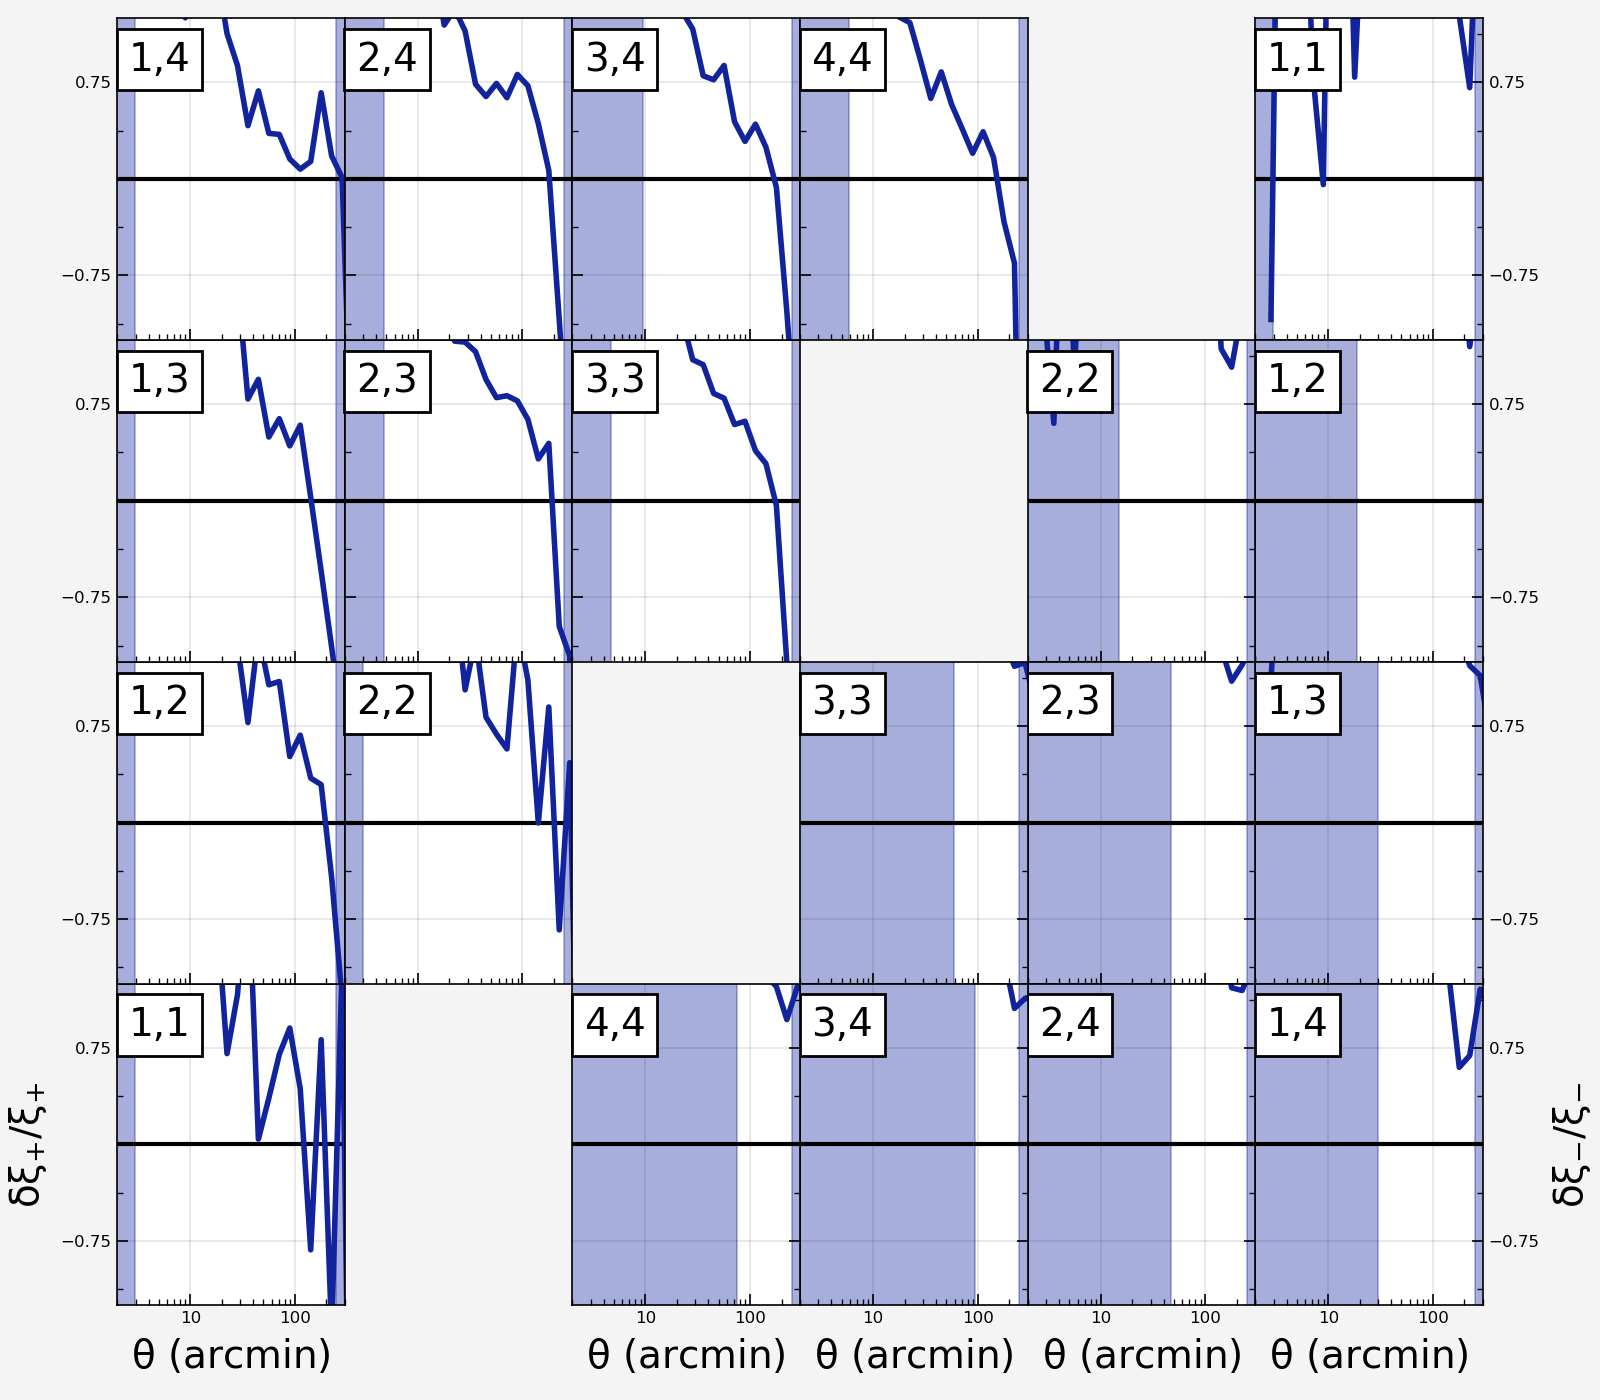

4
xip 1 1
xip 1 1
yes!
Abc
yes!
yes!
yes!
yes!
yes!
yes!
xim 1 4
xim 1 4
yes!
xim 2 4
xim 2 4
xim 3 4
xim 3 4
here
xim 4 4
xim 4 4


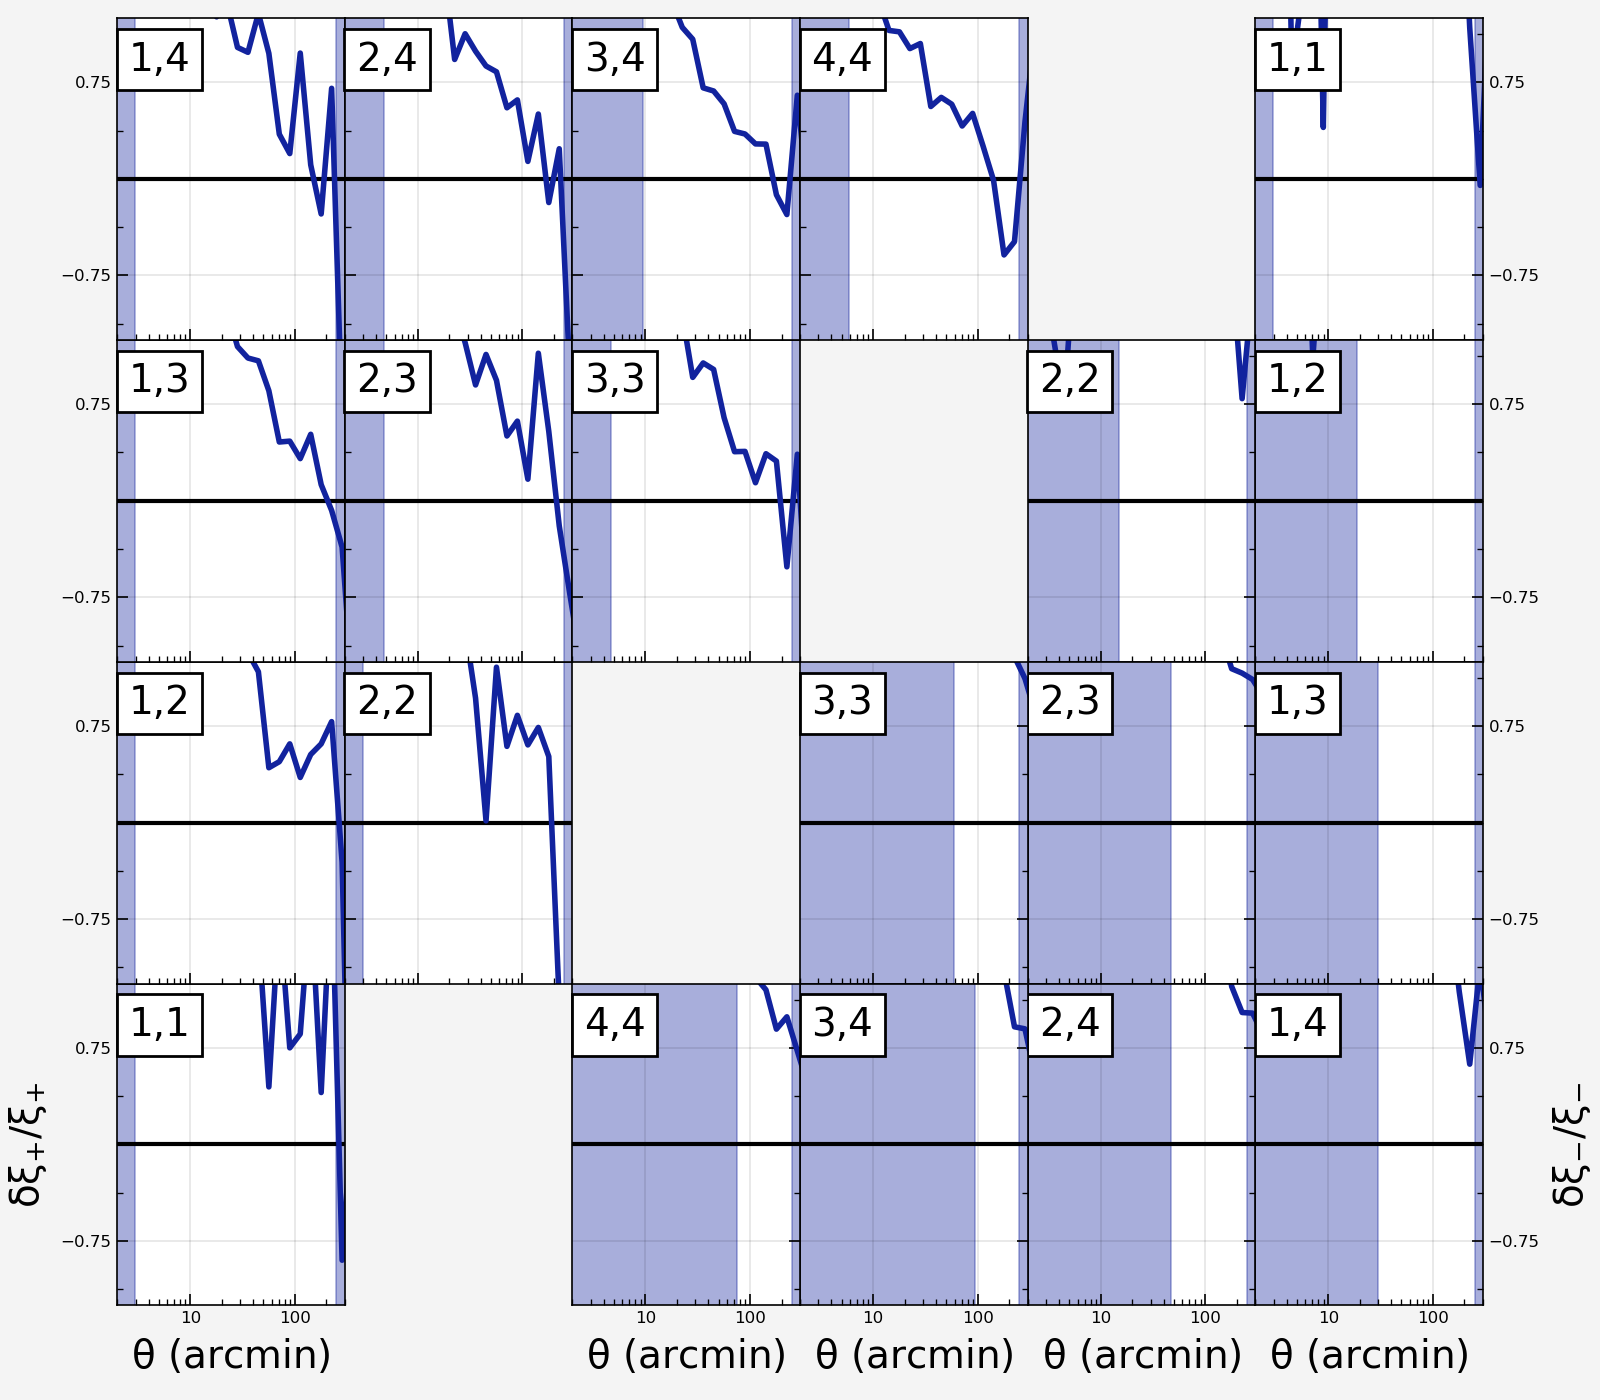

In [31]:
#PLOT DATA VECTOR

import proplot as pplt
import twopoint as tp

catalogs = {'low': {'mdet': infile_mdet_low, 'theory':infile_theory_low}, 'high': {'mdet': infile_mdet_high, 'theory':infile_theory_high}}
for cat in catalogs.keys():
    
    plt.figure(figsize=(8,7))
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "font.size": 6,
        "font.serif": ["Times New Roman"],
    })


    fits   = catalogs[cat]['mdet']
    tfits  = catalogs[cat]['theory']

    xip_   = tp.TwoPointFile.from_fits(fits).get_spectrum('xip')
    xim_   = tp.TwoPointFile.from_fits(fits).get_spectrum('xim')
    txip_   = tp.TwoPointFile.from_fits(tfits).get_spectrum('xip')
    txim_   = tp.TwoPointFile.from_fits(tfits).get_spectrum('xim')

    pairs  = xip_.bin_pairs
    rowcols = np.max(xip_.bin2)
    print(rowcols)

    for k,(i,j) in enumerate(pairs):
        theta  = xip_.get_pair(i,j)[0]
        xip    = xip_.get_pair(i,j)[1]
        xim    = xim_.get_pair(i,j)[1]
        txip    = txip_.get_pair(i,j)[1]
        txim    = txim_.get_pair(i,j)[1]
        xiperr = xip_.get_error(i,j)
        ximerr = xim_.get_error(i,j)
        plot_simpanel('xip',i,j,rowcols,rowcols,theta,xip,xiperr,theta,txip,notomo=False)
        plot_simpanel('xim',i,j,rowcols,rowcols,theta,xim,ximerr,theta,txim,notomo=False)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.0,wspace=0.0)
    # plt.savefig('/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/delta_xi_PSFcontamination_2.5_25_20bins_werrors_maxcont.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

### Get chi2

In [10]:
# get chi2
dlow = fio.FITS(infile_mdet_low); dlow_theory = fio.FITS(infile_theory_low_s8)
C = dlow_theory['COVMAT'].read()
slice_ = []; nbins = 20; nbins_template = 26
for i in range(2*10):
    slice_.append(np.arange(0, nbins) + i*nbins_template)
slice_ = np.array(slice_).reshape(-1)
C_new = C[slice_, :][: , slice_] * 2
Cinvtheory = np.linalg.inv(C_new)


dhigh = fio.FITS(infile_mdet_high); dhigh_theory = fio.FITS(infile_theory_high_s8)
C = dlow['COVMAT'].read()
C_new = C[slice_, :][: , slice_] * 2
Cinvmdet = np.linalg.inv(C_new)


dtheory_xip = dhigh_theory['xip']['VALUE'].read() - dlow_theory['xip']['VALUE'].read()
dtheory_xim = dhigh_theory['xim']['VALUE'].read() - dlow_theory['xim']['VALUE'].read()
dmdet_xip = dhigh['xip']['VALUE'].read() - dlow['xip']['VALUE'].read()
dmdet_xim = dhigh['xim']['VALUE'].read() - dlow['xim']['VALUE'].read()
Dtheory = np.hstack((dtheory_xip[slice_[:200]],dtheory_xim[slice_[:200]]))
Dmdet = np.hstack((dmdet_xip[slice_[:200]],dmdet_xim[slice_[:200]]))

chi2_theory = Dtheory.T @ Cinvtheory @ Dtheory
chi2_mdet = Dmdet.T @ Cinvmdet @ Dmdet
dof = 400

print(chi2_theory, chi2_mdet)
print('chi2/dof for theory sample:', chi2_theory/dof)
print('chi2/dof for mdet sample:', chi2_mdet/dof)

294.3416157790362 2653.822284310736
chi2/dof for theory sample: 0.7358540394475905
chi2/dof for mdet sample: 6.63455571077684


# 4. Additive bias correction

In [7]:
def assign_loggrid(x, y, xmin, xmax, xsteps, ymin, ymax, ysteps):
    """
    Computes indices of 2D grids. Only used when we use shear weight that is binned by S/N and size ratio. 
    """
    from math import log10
    # return x and y indices of data (x,y) on a log-spaced grid that runs from [xy]min to [xy]max in [xy]steps

    logstepx = log10(xmax/xmin)/xsteps
    logstepy = log10(ymax/ymin)/ysteps

    indexx = (np.log10(x/xmin)/logstepx).astype(int)
    indexy = (np.log10(y/ymin)/logstepy).astype(int)

    indexx = np.maximum(indexx,0)
    indexx = np.minimum(indexx, xsteps-1)
    indexy = np.maximum(indexy,0)
    indexy = np.minimum(indexy, ysteps-1)

    return indexx,indexy

def _find_shear_weight(d, mask, wgt_dict, snmin, snmax, sizemin, sizemax, steps, mdet_mom):

    """
    Assigns shear weights to the objects based on the grids. 
    """
    
    if wgt_dict is None:
        weights = np.ones(len(d))
        return weights

    shear_wgt = wgt_dict['weight']
    smoothing = True
    if smoothing:
        from scipy.ndimage import gaussian_filter
        smooth_response = gaussian_filter(wgt_dict['response'], sigma=2.0)
        shear_wgt = (smooth_response/wgt_dict['meanes'])**2
    indexx, indexy = assign_loggrid(np.array(d[mdet_mom+'_s2n'])[mask], np.array(d[mdet_mom+'_T_ratio'])[mask], snmin, snmax, steps, sizemin, sizemax, steps)
    weights = np.array([shear_wgt[x, y] for x, y in zip(indexx, indexy)])
    
    return weights


def _get_shear_weights(dat, mask, weight_file):
    shape_err = False
    if shape_err:
        return 1/(0.22**2 + 0.5*(np.array(dat['gauss_g_cov_1_1'])[mask] + np.array(dat['gauss_g_cov_2_2'])[mask]))
    else:
        with open(os.path.join(weight_file), 'rb') as handle:
            wgt_dict = pickle.load(handle)
            snmin = wgt_dict['xedges'][0]
            snmax = wgt_dict['xedges'][-1]
            sizemin = wgt_dict['yedges'][0]
            sizemax = wgt_dict['yedges'][-1]
            steps = len(wgt_dict['xedges'])-1
        shear_wgt = _find_shear_weight(dat, mask, wgt_dict, snmin, snmax, sizemin, sizemax, steps, 'gauss')
        return shear_wgt
    

def _wmean(q,w):
    return np.sum(q*w)/np.sum(w)

def read_mdet_h5_tomobin_master(datafile, keys, patch_id=None, response=False, subtract_mean_shear=False):
    
    tomobins = ['/tomo_bin_0', '/tomo_bin_1', '/tomo_bin_2', '/tomo_bin_3']
    data_all = {}; mean_shear = {}
    for t in tomobins:
    
        import h5py as h5
        f = h5.File(datafile, 'r')
        # d = f.get('noshear'+t)
        d = f.get('noshear'+t)
        if patch_id is None:
            nrows = len(np.array( d['ra'] ))
            mask = np.ones(nrows)!=0
        else:
            mask = (np.array( d['patch_num'] ) == patch_id)
            nrows = len(np.array( d['ra'] )[mask])
        formats = []
        for key in keys:
            formats.append('f4')
        data = np.recarray(shape=(nrows,), formats=formats, names=keys)

        data_all[t[-5:]] = data
        for key in keys:  
            if key == 'R':
                continue
            elif key in ('g1', 'g2'):
                data[key] = np.array(d['gauss_'+key[0]+'_'+key[1]])[mask]
            elif key in ('g1_cov', 'g2_cov'):
                data[key] = np.array(d['gauss_'+key[0]+'_cov_'+key[1]+'_'+key[1]])[mask]
            else:
                data[key] = np.array(d[key])[mask]
        print('made recarray with hdf5 file')

        # response correction
        if response:
            d_2p = f.get('2p'+t); nrows = len(np.array( d_2p['ra'] )); mask_2p = np.ones(nrows)!=0
            d_1p = f.get('1p'+t); nrows = len(np.array( d_1p['ra'] )); mask_1p = np.ones(nrows)!=0
            d_2m = f.get('2m'+t); nrows = len(np.array( d_2m['ra'] )); mask_2m = np.ones(nrows)!=0
            d_1m = f.get('1m'+t); nrows = len(np.array( d_1m['ra'] )); mask_1m = np.ones(nrows)!=0
            # compute response with weights
            g1p = _wmean(np.array(d_1p["gauss_g_1"]), np.array(d_1p['w']))                                     
            g1m = _wmean(np.array(d_1m["gauss_g_1"]), np.array(d_1m['w']))
            R11 = (g1p - g1m) / 0.02

            g2p = _wmean(np.array(d_2p["gauss_g_2"]), np.array(d_2p['w']))
            g2m = _wmean(np.array(d_2m["gauss_g_2"]), np.array(d_2m['w']))
            R22 = (g2p - g2m) / 0.02

            R = (R11 + R22)/2.
            print('weighted shear response is ', R)
            data['g1'] /= R
            data['g2'] /= R

            mean_g1 = _wmean(data['g1'], data['w'])
            mean_g2 = _wmean(data['g2'], data['w'])
            std_g1 = np.var(data['g1'])
            std_g2 = np.var(data['g2'])
            mean_shear[t[-5:]] = [mean_g1, mean_g2]
            # mean shear subtraction
            if subtract_mean_shear:
                print('subtracting mean shear')
                print('mean g1 g2 =(%1.8f,%1.8f)'%(mean_g1, mean_g2))          
                data['g1'] -= mean_g1
                data['g2'] -= mean_g2
                
    return data_all, mean_shear

In [9]:
f = '/global/cfs/cdirs/des/y6-shear-catalogs/master/metadetect_2024-11-07.hdf5'
wgt_file = "/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/inverse_variance_weight_v6.pickle"

In [10]:
e1 = []; e2 = []
keys = ['g1', 'g2', 'w']
d, mean_shear = read_mdet_h5_tomobin_master(f, keys, response=True, subtract_mean_shear=True)
for t in ['/tomo_bin_0', '/tomo_bin_1', '/tomo_bin_2', '/tomo_bin_3']:
    e1.append(mean_shear[t[-5:]][0]); e2.append(mean_shear[t[-5:]][1])

made recarray with hdf5 file
weighted shear response is  0.8561433330298949
subtracting mean shear
mean g1 g2 =(0.00016388,0.00006174)
made recarray with hdf5 file
weighted shear response is  0.868505678503587
subtracting mean shear
mean g1 g2 =(0.00004460,-0.00005780)
made recarray with hdf5 file
weighted shear response is  0.8194268015985409
subtracting mean shear
mean g1 g2 =(0.00024206,-0.00016926)
made recarray with hdf5 file
weighted shear response is  0.6917685743283774
subtracting mean shear
mean g1 g2 =(0.00030604,0.00011363)


In [17]:
imax=26
dvfits   = theory_fid_dv

xip_   = tp.TwoPointFile.from_fits(dvfits).get_spectrum('xip')
xim_   = tp.TwoPointFile.from_fits(dvfits).get_spectrum('xim')
pairs  = xip_.bin_pairs
rowcols = np.max(xip_.bin2)
#print(rowcols)

theory_xip = []; theory_xim = []
new_xip = []; new_xim = []
for k,(i,j) in enumerate(pairs):
    theta  = xip_.get_pair(i,j)[0][:imax]
    xip    = xip_.get_pair(i,j)[1][:imax]
    xim    = xim_.get_pair(i,j)[1][:imax]
    
    xip_add = xip + (e1[i-1]*e1[j-1] + e2[i-1]*e2[j-1])
    xim_add = xim + (e1[i-1]*e1[j-1] - e2[i-1]*e2[j-1])
    new_xip.append(xip_add); new_xim.append(xim_add)
    theory_xip.append(xip); theory_xim.append(xim)

new_xip = np.concatenate(new_xip); theory_xip = np.concatenate(theory_xip)
new_xim = np.concatenate(new_xim); theory_xim = np.concatenate(theory_xim)

In [25]:
# Make new fits file that is contaminated
def copy_header(f, name, out_f):
    # this generically copies over a HDU from the template file
    # for the moment we want to do this for gammat and wtheta
    # as placeholders until we have the real thing

    hdr = f[name].read_header()
    data = f[name].read()

    out_f.write(data)
    out_f[-1].write_key('EXTNAME',name)
    for k in hdr.keys():
        if k=='EXTNAME':
            continue

        out_f[-1].write_key(k,hdr[k])

    print('done copying %s'%name)

def copy_covariance(f, nbins, out_f, shear_only=True):
    # this basically just copies across an analytic covariance matrix
    C = f['COVMAT'].read()
    hdr = f['COVMAT'].read_header()

    n_xip = nbins; n_xim = nbins

    if shear_only:
        out_f.write(C[:10*nbins*2, :10*nbins*2])
        out_f[-1].write_key('EXTNAME', 'COVMAT')
        out_f[-1].write_key('STRT_0', hdr['STRT_0'])
        out_f[-1].write_key('NAME_0', 'xip')
        out_f[-1].write_key('STRT_1', hdr['STRT_1'])
        out_f[-1].write_key('NAME_1', 'xim')
    else:
        out_f.write(C)
        out_f[-1].write_key('EXTNAME', 'COVMAT')
        out_f[-1].write_key('STRT_0', hdr['STRT_0'])
        out_f[-1].write_key('NAME_0', 'xip')
        out_f[-1].write_key('STRT_1', hdr['STRT_1'])
        out_f[-1].write_key('NAME_1', 'xim')
        out_f[-1].write_key('STRT_2', hdr['STRT_2'])
        out_f[-1].write_key('NAME_2', 'gammat')
        out_f[-1].write_key('STRT_3', hdr['STRT_3'])
        out_f[-1].write_key('NAME_3', 'wtheta')


dvfits = '/pscratch/sd/m/myamamot/y6-3x2pt-methods/cosmosis/data_vectors/FIDUCIAL_DVv5.0.fits'
fits_file = fio.FITS(dvfits)
theta, theta_min, theta_max, xip, xim, _, _, _ = np.loadtxt('/global/cfs/cdirs/des/myamamot/y6-cosmicshear/mdet/measurements/xipm_y6_mastermdetV6_UNBLINDED_v6cuts_bin_0_0_0.010slop_2.5theta1000.0.txt').T

# new file
out_file = fio.FITS('/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/FIDUCIAL_DVv5.0_econt.fits','rw')

copy_header(fits_file, 'nz_source', out_file)
# copy_header(fits_file, 'nz_lens', out_file)

# add theta info
info_xip = {'BIN1': [],'BIN2': [],'ANGBIN': [],'VALUE': [],'ANG': [],'ANGLEMIN': [],'ANGLEMAX': []}
info_xim = {'BIN1': [],'BIN2': [],'ANGBIN': [],'VALUE': [],'ANG': [],'ANGLEMIN': [],'ANGLEMAX': []}


tomobins = [(1,1), (1,2), (1,3), (1,4), (2,2), (2,3), (2,4), (3,3), (3,4), (4,4)]
xip_   = tp.TwoPointFile.from_fits(dvfits).get_spectrum('xip')
xim_   = tp.TwoPointFile.from_fits(dvfits).get_spectrum('xim')
for i,j in tomobins:
    
    xip    = xip_.get_pair(i,j)[1] + (e1[i-1]*e1[j-1] + e2[i-1]*e2[j-1])
    xim    = xim_.get_pair(i,j)[1] + (e1[i-1]*e1[j-1] - e2[i-1]*e2[j-1])
    
    i_theta = np.arange(0, len(theta), 1)
    info_xip['VALUE'].append(xip)
    info_xip['ANG'].append(theta)
    info_xip['ANGLEMIN'].append(theta_min)
    info_xip['ANGLEMAX'].append(theta_max)
    info_xip['ANGBIN'].append(i_theta.astype(int))
    info_xip['BIN1'].append((np.ones_like(xip) * i).astype(int))
    info_xip['BIN2'].append((np.ones_like(xip) * j).astype(int))

    info_xim['VALUE'].append(xim)
    info_xim['ANG'].append(theta)
    info_xim['ANGLEMIN'].append(theta_min)
    info_xim['ANGLEMAX'].append(theta_max)
    info_xim['ANGBIN'].append(i_theta.astype(int))
    info_xim['BIN1'].append((np.ones_like(xim) * i).astype(int))
    info_xim['BIN2'].append((np.ones_like(xim) * j).astype(int))

for k in info_xip.keys():
    info_xip[k] = np.concatenate(info_xip[k])
    info_xim[k] = np.concatenate(info_xim[k])

out_file.write(info_xip)

out_file[-1].write_key('EXTNAME', 'xip')
out_file[-1].write_key('KERNEL_1', 'nz_source')
out_file[-1].write_key('KERNEL_2', 'nz_source')
out_file[-1].write_key('WINDOWS', 'SAMPLE')
out_file[-1].write_key('N_ZBIN_1', 4)
out_file[-1].write_key('N_ZBIN_2', 4)
out_file[-1].write_key('N_ANG', len(theta))
out_file[-1].write_key('TUNIT5', 'arcmin')
out_file[-1].write_key('TUNIT6', 'arcmin')
out_file[-1].write_key('TUNIT7', 'arcmin')
out_file[-1].write_key('2PTDATA', True)
out_file[-1].write_key('QUANT1', 'G+R')
out_file[-1].write_key('QUANT2', 'G+R')

out_file.write(info_xim)

out_file[-1].write_key('EXTNAME', 'xim')
out_file[-1].write_key('KERNEL_1', 'nz_source')
out_file[-1].write_key('KERNEL_2', 'nz_source')
out_file[-1].write_key('WINDOWS', 'SAMPLE')
out_file[-1].write_key('N_ZBIN_1', 4)
out_file[-1].write_key('N_ZBIN_2', 4)
out_file[-1].write_key('N_ANG', len(theta))
out_file[-1].write_key('TUNIT5', 'arcmin')
out_file[-1].write_key('TUNIT6', 'arcmin')
out_file[-1].write_key('TUNIT7', 'arcmin')
out_file[-1].write_key('2PTDATA', True)
out_file[-1].write_key('QUANT1', 'G-R')
out_file[-1].write_key('QUANT2', 'G-R')

# Add gammat, wtheta as well.
# copy_header(fits_file, 'gammat', out_file)
# copy_header(fits_file, 'wtheta', out_file)


# Add covariance
copy_covariance(fits_file, len(theta), out_file)


# C_ = np.random.rand(nt*20, nt*20)
# C = np.dot(C_, C_.transpose())
# hdr = fits_file['COVMAT'].read_header()
# out_file.write(C)
# out_file[-1].write_key('EXTNAME', 'COVMAT')
# out_file[-1].write_key('STRT_0', hdr['STRT_0'])
# out_file[-1].write_key('NAME_0', 'xip')
# out_file[-1].write_key('STRT_1', hdr['STRT_1']
# out_file[-1].write_key('NAME_1', 'xim')
# out_file[-1].write_key('STRT_2', hdr['STRT_2'])
# out_file[-1].write_key('NAME_2', 'gammat')
# out_file[-1].write_key('STRT_3', hdr['STRT_3'])
# out_file[-1].write_key('NAME_3', 'wtheta')


out_file.close()

done copying nz_source


In [12]:
nbins = 20; nbins_template = 26
d = fio.FITS(dvfits)
C = d['COVMAT'].read()[:nbins_template*len(pairs)*2, :nbins_template*len(pairs)*2] # including extra scales results in 26 bins -> 520x520 cov mat.

slice_ = []
for i in range(nbins):
    slice_.append(np.arange(0, imax) + i*nbins_template)
slice_ = np.array(slice_).reshape(-1)
# print(slice_)
C = C[slice_, :][:, slice_]

Cinv = np.linalg.inv(C)

Dadd = np.hstack((new_xip,new_xim))
Dtheory = np.hstack((theory_xip,theory_xim))

chi2_theory = Dtheory.T @ Cinv @ Dtheory
chi2_add = Dadd.T @ Cinv @ Dadd
dof = nbins*len(pairs)*2

print('chi2/dof for theory sample:', chi2_theory/dof)
print('chi2/dof for additive bias contaminated sample:', chi2_add/dof)
print('delta chi2: ', (chi2_add/dof - chi2_theory/dof))

chi2/dof for theory sample: 7.352764302944017
chi2/dof for additive bias contaminated sample: 7.488526621012586
delta chi2:  0.13576231806856853


xip 1 1
xip 1 1
yes!
Abc
yes!
yes!
yes!
yes!
yes!
yes!
xim 1 4
xim 1 4
yes!
xim 2 4
xim 2 4
xim 3 4
xim 3 4
here


findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


xim 4 4
xim 4 4


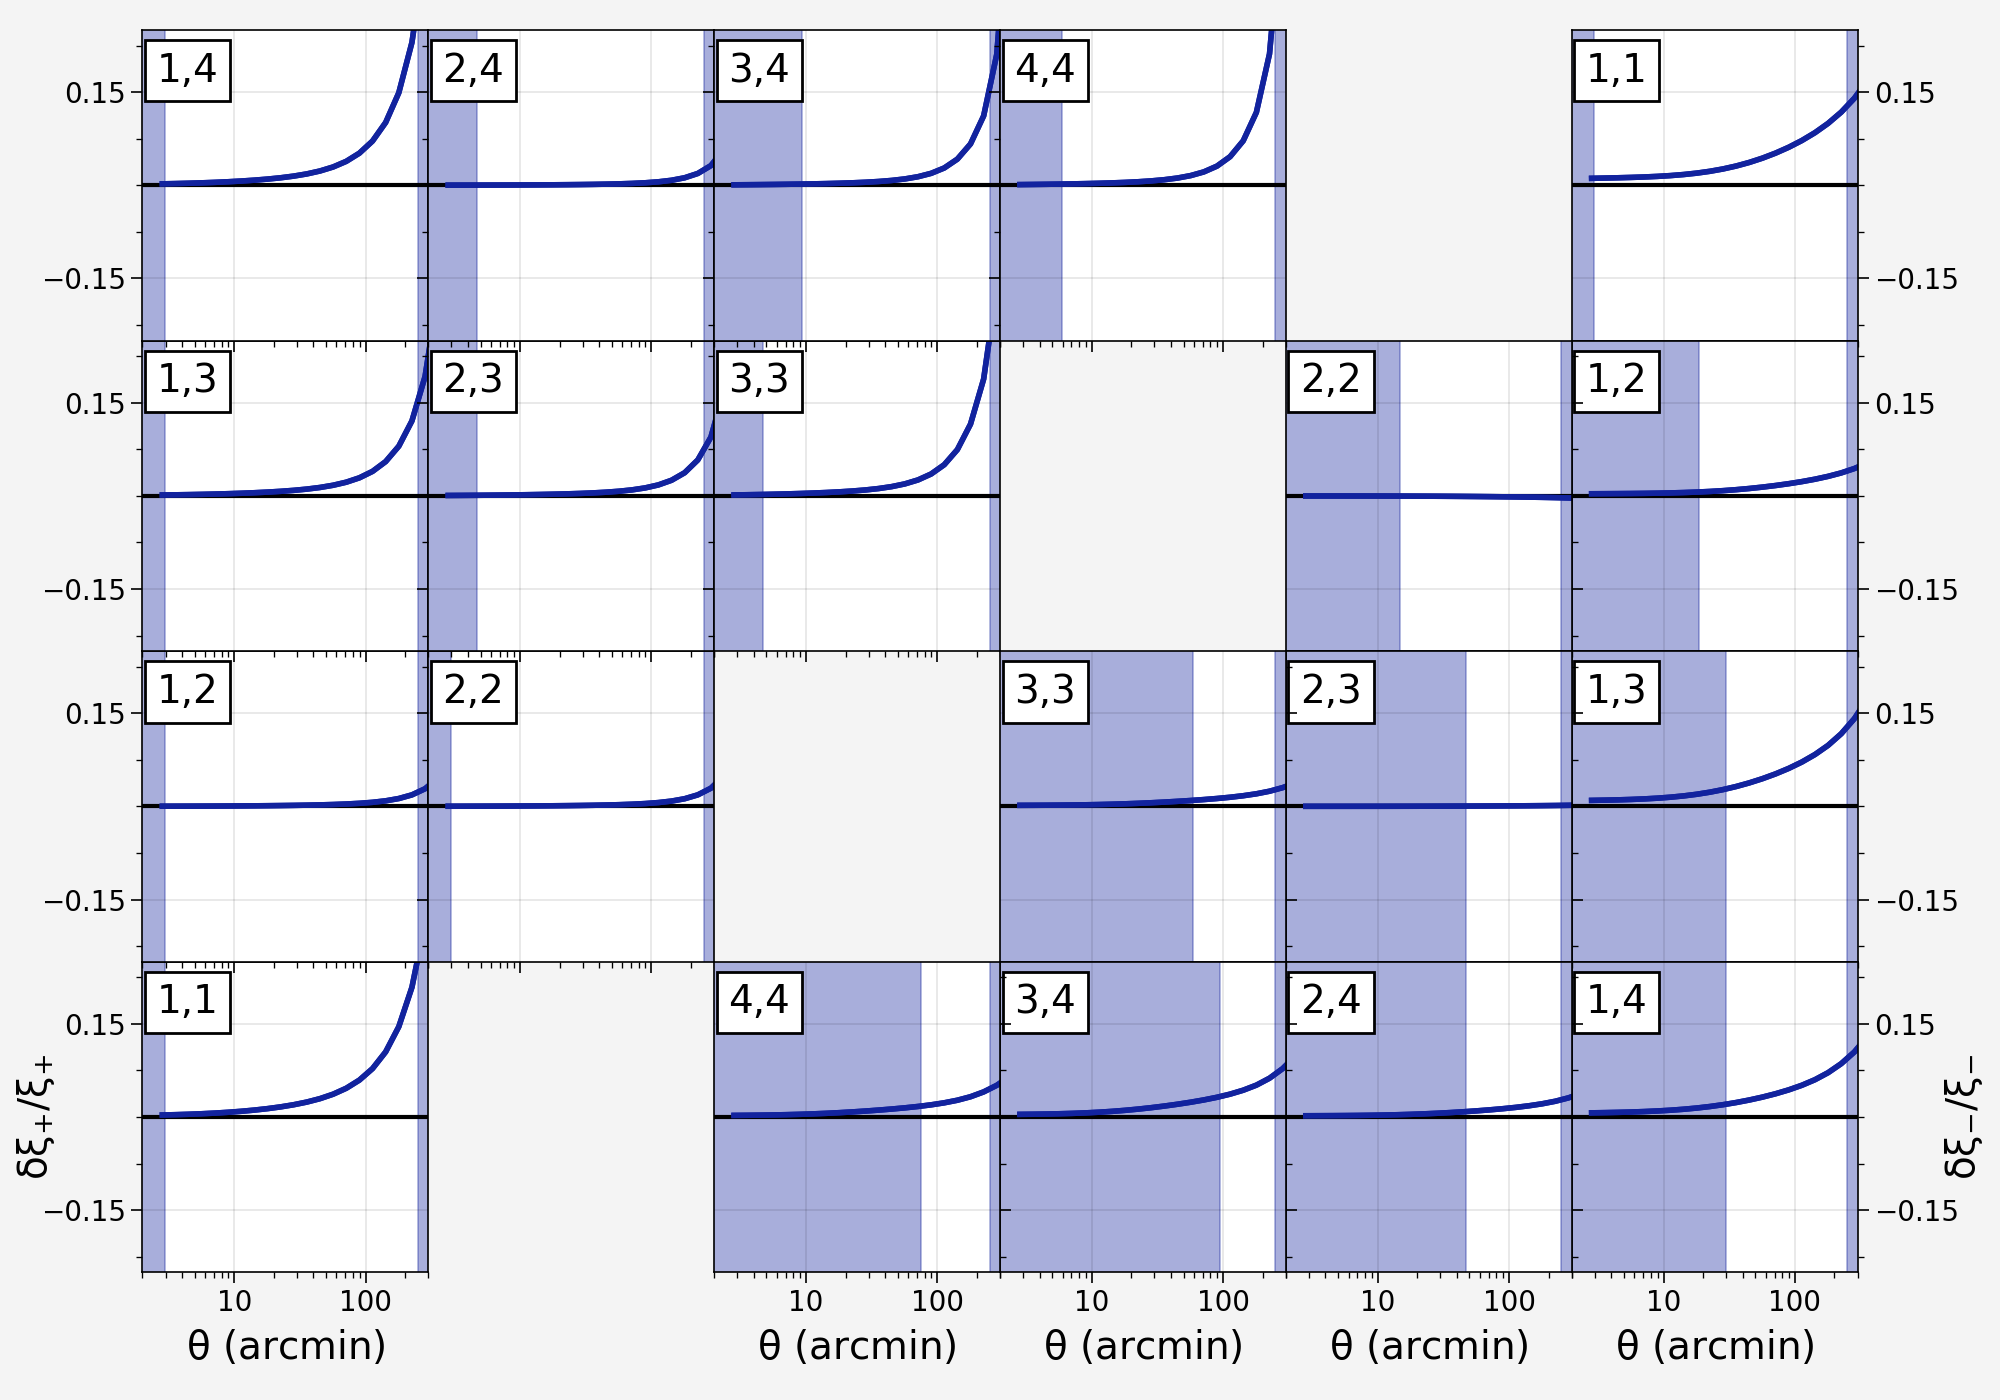

In [13]:
log=False
matplotlib.rcParams["xtick.direction"]='in'
matplotlib.rcParams["ytick.direction"]='in'

def get_axes_(name,i,j,rows,cols,dxi=False):
    if not dxi:
        if name == 'xip':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(3-(j-1)),i-1),rowspan=2)
        elif name=='xim':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(j-1),6-i),rowspan=2)
    else:
        if name == 'xip':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(3-(j-1))+2,i-1))
        elif name=='xim':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(j-1)+2,6-i))
    return ax


def get_angle_range_agg(xi,j,i):
    config = configparser.ConfigParser()
    config.read(scfile)
    scales = config['2pt_like']
    if xi == 'xip':
        name = 'angle_range_xip_'+str(j)+'_'+str(i)
    else:
        name = 'angle_range_xim_'+str(j)+'_'+str(i)
        #print(name, str(j), str(i), np.array(scales[name].split()).astype(float))
    return np.array(scales[name].split()).astype(float)

def get_angle_range(xi,j,i):
    config = configparser.ConfigParser()
    config.read(scfile)
    scales = config['2pt_like']

    if xi == 'xip':
        name = 'angle_range_xip_'+str(j)+'_'+str(i)
    else:
        name = 'angle_range_xim_'+str(j)+'_'+str(i)
    return np.array(scales[name].split()).astype(float)

def get_params(xi,theta):
    if xi == 'xip' or xi == 'xim':
        #lims = [(-0.5,4.4),(0.,4.4),(0.,4.4),(0.,4.4)]#[(-0.4,1.2),(-0.4,1.6),(-0.6,3.),(-0.6,4.45)]
        lims = [(-0.5,4.5),(-0.5,4.5),(-0.5,4.5),(-0.5,4.5)]#[(-0.4,1.2),(-0.4,1.6),(-0.6,3.),(-0.6,4.45)]


        dlims = [(-1.5,2.5) for i in range(4)]
        tmult = theta
        dmult = 1e4
        dmult2 = 1e4
        lx = [0.05, 0.93]
    return lims, dlims,tmult,dmult,dmult2,lx

def set_axes(name,ax,dxi=False):
    if not dxi:
        if (name=='xim')&(i==1):
            plt.xlabel(r'$\theta$ [arcmin]')
        else:
            ax.set_xticklabels([])
        if i!=1:
            ax.set_yticklabels([])
        if (i==1)&(j==1):
            if name == 'xip':
                print("123")
                # plt.ylabel(r'$   10^{4}\theta\xi_{+}    $', labelpad=15) 
                plt.ylabel(r'$\theta\xi_{+}    $', labelpad=15) 
                x,y = ax.yaxis.label.get_position()
                print(x,y)
                ax.yaxis.set_label_coords(x-.2, y)#-0.5
        if (i==1)&(j==4):
            if name == 'xim':
                # plt.ylabel(r'$   10^{4}\theta\xi_{-}     $')
                plt.ylabel(r'$\theta\xi_{-}    $', labelpad=15) 
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x+1.2, y)#+0.5
                ax.yaxis.set_label_position("right")
    else:
        if (name=='xim')&(j==4): #&(j==4):
            print(name,i,j)
            plt.xlabel(r'$\theta$ (arcmin)')
        elif (name=='xip')&(i==1)&(j==1):
            print(name,i,j)
            plt.xlabel(r'$\theta$ (arcmin)')
        if (name=='xim')&(j<3):
            ax.set_xticklabels([])
        if (name=='xip')&(j!=1):
        #else:
            ax.set_xticklabels([])
        
        if (name=='xip')&(i==1):
            print("yes!")
            #ax.set_yticklabels([])
        elif (name=='xim')&(i==1):
            print("yes!")
        else:
            ax.set_yticklabels([])
            
        if (i==1)&(j==1):
            if name == 'xip':
                print("Abc")
                plt.ylabel(r'$\delta\xi_{+}/\xi_{+}      $')
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x-.2, y)#-0.5
        if (i==1)&(j==4):
            if name == 'xim':
                plt.ylabel(r'$\delta\xi_{-}/\xi_{-}      $')
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x+1.2, y)#+0.5
                ax.yaxis.set_label_position("right")

def get_axes_sim(name,i,j,rows,cols,dxi=False):
    if name == 'xip':
        ax = plt.subplot2grid((cols,rows+2), ((3-(j-1)),i-1))
    elif name=='xim':
        ax = plt.subplot2grid(( cols,rows+2), ((j-1),6-i))
    
    return ax

def plot_panel_(name,i,j,rows,cols,theta,xi,err,ttheta,txi,notomo=False):
    lims, dlims,tmult,dmult,dmult2,lx = get_params(name,theta)
    ax = get_axes_(name,i,j,rows,cols)
    tmin,tmax = get_angle_range(name,i,j)
    tmin2,tmax2 = get_angle_range_agg(name,i,j)
    ax.axhline(y=0,ls='--',color='k',lw=0.8)

    from matplotlib.ticker import ScalarFormatter
    for axis in [ax.xaxis, ax.yaxis]:
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        axis.set_major_formatter(formatter)
    ax.plot(ttheta,tmult*txi*dmult,ls='-',color = '#016e51',linewidth=3.)
    # ax.errorbar(theta,tmult*xi*dmult,yerr=err*tmult*dmult,ls='',marker='.',color = 'k')
    # ax.plot(theta,tmult*xi*dmult,ls='',marker='.',color = 'k')
    ax.plot(theta,tmult*xi*dmult,ls='-', color = 'k')
    ax.set_rasterization_zorder(0)
    if txi is None:
        print('faking theory')
        txi = fake_theory(xi)

    plt.ylim(lims[j-1])
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    ax.text(lx[0], lx[1], str(i)+','+str(j), transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)
    plt.xlim((2,300))
    #plt.ticklabel_format(axis='x',style='plain',useOffset=False)    
    set_axes(name,ax,)
    plt.yticks((1.0,3.0))
    plt.xscale('log')
    ax.set_xlabel('')
    #ax.ticklabel_format(style='plain')
    plt.minorticks_on()
    if name == 'xim':
        ax.yaxis.tick_right()
    #ax.spines[axis].set_linewidth(0.5)
    
    ax = get_axes_(name,i,j,rows,cols,dxi=True)
    tmin,tmax = get_angle_range(name,i,j)
    ax.axhline(y=0,ls='-',color='k')
    ax.errorbar(theta,(xi-txi)/txi,yerr=err/txi,ls='',marker='.',color = 'k')
    ax.set_rasterization_zorder(0)
    plt.ylim(-1.0,1.0)
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    #props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    #ax.text(0.03, 0.93, str(i)+','+str(j), transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    plt.xlim((2,300))
    plt.yticks((-1.0,1.0))
    plt.xscale('log')
    # plt.yscale('symlog',linthreshy=.01,linscale=0.01)
    from matplotlib.ticker import FuncFormatter
    x=theta
    formatter = FuncFormatter(lambda x, _: '{:.16g}'.format(x)) # https://stackoverflow.com/a/49306588/3904031
    ax.xaxis.set_major_formatter(formatter)
    set_axes(name,ax,dxi=True)
    #plt.minorticks_on()
    if name == 'xim':
        ax.yaxis.tick_right()
        
def plot_simpanel(name,i,j,rows,cols,theta,xi,err,ttheta,txi,notomo=False):
    lims, dlims,tmult,dmult,dmult2,lx = get_params(name,theta)

    ax = get_axes_sim(name,i,j,rows,cols,dxi=True)
    tmin,tmax = get_angle_range(name,i,j)
    tmin2,tmax2 = get_angle_range_agg(name,i,j)
    ax.set_rasterization_zorder(0)
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    ax.axhline(y=0,ls='-',color='k')
    
    ax.plot(theta,(xi-txi)/(txi),ls='-', color = '#12239e',linewidth=2., label=r'C')
    ax.errorbar(theta, (xi-txi)/(txi), yerr=err, fmt='-', color = '#12239e',linewidth=2., capsize=0.0)
    # ax.plot(theta,(max_xi_cont-xi)/(xi),ls='--', color = '#59db2a',linewidth=1.5, label=r'C')
    # ax.fill_between(theta, -err, err, color = '#9aeb77' , alpha = 0.2)
    
    plt.ylim((-0.25,0.25))
    plt.yticks((-0.15,.15))
        
    if (i==1)&(j==1):
        if name == 'xip':               
            x,y = ax.yaxis.label.get_position()
            ax.yaxis.set_label_coords(x-0.1, y)#-0.5
            plt.ylabel(r'$\delta\xi_+/\xi_+}$', fontsize=14)
    if (i==1)&(j==4):
        if name == 'xim':
            x,y = ax.yaxis.label.get_position()
            ax.yaxis.set_label_coords(x+0.1, y)#+0.5
            ax.yaxis.set_label_position("right")
            plt.ylabel(r'$\delta\xi_-/\xi_-$', fontsize=14)
    
    if (name=='xim')&(j==4):
        print(name,i,j)
        plt.xlabel(r'$\theta$ (arcmin)', fontsize=14)
    elif (name=='xip')&(i==1)&(j==1):
        print(name,i,j)
        plt.xlabel(r'$\theta$ (arcmin)', fontsize=14)
    
    plt.xlim((2,300))
    plt.xticks((10,100))
    plt.xscale('log')
    from matplotlib.ticker import FuncFormatter
    x=theta
    formatter = FuncFormatter(lambda x, _: '{:.16g}'.format(x)) # https://stackoverflow.com/a/49306588/3904031
    ax.xaxis.set_major_formatter(formatter)
    set_axes(name,ax,dxi=True)
    

    if (name=='xip')&(j!=1):
        ax.set_xticklabels([])
        # ax.set_xticks([])
    if (name=='xip')&(i!=1):
        ax.set_yticklabels([])
    if (name=='xim')&(j!=4):
        ax.set_xticklabels([])


    plt.minorticks_on()
    if name == 'xim':
        ax.yaxis.tick_right()

    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    #ax.text(0.03, 0.93, str(i)+','+str(j), transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    

    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    ax.text(lx[0], lx[1], str(i)+','+str(j), transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)

    if (i==4) & (j==4) & (name=="xip"):
        print("here")
        #ax.legend(*ax.get_legend_handles_labels(),ncol=4, bbox_to_anchor=(-2.,1.34),loc='upper left', fontsize=14)  ##AC
        
#PLOT DATA VECTOR
import proplot as pplt
import twopoint as tp
plt.figure(figsize=(10,7))
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 10,
    "font.serif": ["Times New Roman"],
})


dvfits   =  dvfits
tfits  =  dvfits

xip_   = tp.TwoPointFile.from_fits(dvfits).get_spectrum('xip')
xim_   = tp.TwoPointFile.from_fits(dvfits).get_spectrum('xim')
txip_   = tp.TwoPointFile.from_fits(tfits,covmat_name=None).get_spectrum('xip')
txim_   = tp.TwoPointFile.from_fits(tfits,covmat_name=None).get_spectrum('xim')
pairs  = xip_.bin_pairs
rowcols = np.max(xip_.bin2)
#print(rowcols)

for k,(i,j) in enumerate(pairs):
    theta  = xip_.get_pair(i,j)[0]
    xip    = xip_.get_pair(i,j)[1] + (e1[i-1]*e1[j-1] + e2[i-1]*e2[j-1])
    xim    = xim_.get_pair(i,j)[1] + (e1[i-1]*e1[j-1] - e2[i-1]*e2[j-1])
    xiperr = 0 # xip_.get_error(i,j)
    ximerr = 0 # xim_.get_error(i,j)
    txip    = txip_.get_pair(i,j)[1]
    txim    = txim_.get_pair(i,j)[1]

    # plot_panel_('xip',i,j,rowcols,rowcols,theta,xip,xiperr,theta,txip,notomo=False)
    # plot_panel_('xim',i,j,rowcols,rowcols,theta,xim,ximerr,theta,txim,notomo=False)
    plot_simpanel('xip',i,j,rowcols,rowcols,theta,xip,xiperr,theta,txip,notomo=False)
    plot_simpanel('xim',i,j,rowcols,rowcols,theta,xim,ximerr,theta,txim,notomo=False)

plt.tight_layout()
plt.subplots_adjust(hspace=0,wspace=0)
# plt.savefig(savedir+'additivebias_DVcomp_delta.pdf', dpi=150,bbox_inches='tight')
plt.show()
plt.close()